# Milestone 3 - Modelação e Avaliação (Objetivo 2: Índice de Risco de Attrition)

Neste notebook é desenvolvido um índice de risco de abandono (`Attrition`), com base nas probabilidades previstas pelo modelo de Regressão Logística (com escalonamento de variáveis via *StandardScaler*), construído especificamente para garantir interpretabilidade e estabilidade probabilística.

Este trabalho enquadra-se nas fases de *Modelling* e *Evaluation* da metodologia CRISP-DM, dando continuidade à etapa anterior (**Objetivo 1**), onde foi estabelecida a *Baseline* preditiva do projeto.

O objetivo principal deste notebook consiste em construir um índice de risco de *attrition*, que permita segmentar os colaboradores em diferentes níveis de risco, com base na probabilidade estimada de abandono, até à data definida para a Milestone 3.

Para esse efeito, os colaboradores são classificados nas seguintes categorias:

- **Baixo risco**: probabilidade de attrition inferior a 30%;
- **Risco médio**: probabilidade entre 30% e 60%;
- **Alto risco**: probabilidade superior a 60%.

Após a obtenção das probabilidades através do modelo selecionado, esta fase tem como propósito:

- Utilizar as probabilidades previstas (`predict_proba`) para estimar o risco individual de abandono de cada colaborador;
- Construir uma variável categórica de risco com base nos limiares definidos;
- Analisar visualmente a distribuição dos colaboradores pelos diferentes níveis de risco(recorrendo a Histogramas e Boxplots);
- Comparar as características médias dos grupos identificados, de forma a compreender o perfil sociodemográfico e laboral associado a cada nível de risco;
- Avaliar a coerência entre o índice de risco construído e a variável alvo real (`Attrition`);
- Interpretar os resultados numa perspetiva de negócio, identificando implicações práticas para a retenção de talento.

A definição dos limiares de segmentação foi orientada por critérios interpretativos e operacionais, permitindo transformar probabilidades contínuas em categorias acionáveis para suporte à decisão.

Este índice de risco constitui uma ferramenta de apoio à gestão, permitindo priorizar ações preventivas de retenção e desenvolver estratégias diferenciadas para colaboradores com diferentes níveis de risco de abandono.

**Autores: Luís Figueira, Martim Ferreira e Mateus Afonso (Figueira,L., Afonso, M. e Ferreira, M.)**

# Índice de Risco - Regressão Logística (Baseline)
Modelo de Regressão Logística com StandardScaler e classificação de risco.

In [1]:
# 1. IMPORTAÇÕES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, RocCurveDisplay,
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings("ignore")
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [2]:
# 2. CARREGAMENTO DO DATASET

#url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
#df = pd.read_csv(url)
#print(f"Dataset carregado: {df.shape[0]} linhas, {df.shape[1]} colunas")

In [3]:
# 3. PREPARAÇÃO DAS FEATURES

#cols_remover = ["Attrition", "OverTime", "Gender",
#                "BusinessTravel", "Department", "EducationField",
#                "JobRole", "MaritalStatus"]

#cols_remover = [c for c in cols_remover if c in df.columns]
#df_model = df.drop(columns=cols_remover)

#TARGET = "Attrition_bin"
#X = df_model.drop(columns=[TARGET])
#y = df_model[TARGET]
#X = X.select_dtypes(include=[np.number])

#print(f"Features utilizadas: {X.shape[1]}")

In [4]:
# 4. DIVISÃO TREINO / TESTE — Gerar
#import os
#import zipfile
#from IPython.display import FileLink, display

#treino_path = "data/processed/Objetivo2/treino"
#teste_path  = "data/processed/Objetivo2/teste"

# 80% treino, 20% teste
# stratify=y — garante a mesma proporção de Yes/No em treino e teste
#X_train, X_test, y_train, y_test = train_test_split(
#    X, y, test_size=0.2, random_state=42, stratify=y
#)

# Criar as pastas e guardar os splits
#os.makedirs(treino_path, exist_ok=True)
#os.makedirs(teste_path, exist_ok=True)
#X_train.to_csv(f"{treino_path}/X_train.csv", index=False)
#y_train.to_csv(f"{treino_path}/y_train.csv", index=False)
#X_test.to_csv(f"{teste_path}/X_test.csv", index=False)
#y_test.to_csv(f"{teste_path}/y_test.csv", index=False)

# Criar ZIP com a estrutura de pastas completa
#zip_path = "data/processed/Objetivo2/splits.zip"
#with zipfile.ZipFile(zip_path, "w") as zipf:
#    zipf.write(f"{treino_path}/X_train.csv", "treino/X_train.csv")
#    zipf.write(f"{treino_path}/y_train.csv", "treino/y_train.csv")
#    zipf.write(f"{teste_path}/X_test.csv",   "teste/X_test.csv")
#    zipf.write(f"{teste_path}/y_test.csv",   "teste/y_test.csv")

#print("Splits gerados! :")
#display(FileLink(zip_path))

In [5]:
# 4. DIVISÃO TREINO / TESTE — CARREGAR DO GITHUB
base_treino = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/Objetivo2/treino"
base_teste  = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/Objetivo2/teste"

# Carregar diretamente do GitHub
X_train = pd.read_csv(f"{base_treino}/X_train.csv")
y_train = pd.read_csv(f"{base_treino}/y_train.csv").squeeze()
X_test  = pd.read_csv(f"{base_teste}/X_test.csv")
y_test  = pd.read_csv(f"{base_teste}/y_test.csv").squeeze()

print(f"Treino: {X_train.shape[0]} obs | Teste: {X_test.shape[0]} obs")

Treino: 1176 obs | Teste: 294 obs


In [6]:
# 5. TREINO — REGRESSÃO LOGÍSTICA (BASELINE)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression())
])

pipeline.fit(X_train, y_train)
print("Modelo treinado.")

Modelo treinado.


In [7]:
# 6. AVALIAÇÃO NO CONJUNTO DE TREINO E TESTE

def avaliar_modelo(pipeline, X, y, nome_conjunto):
    y_pred       = pipeline.predict(X)
    y_pred_proba = pipeline.predict_proba(X)[:, 1]

    acc       = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall    = recall_score(y, y_pred)
    f1        = f1_score(y, y_pred)
    auc       = roc_auc_score(y, y_pred_proba)

    print(f"===== METRICAS — {nome_conjunto} =====")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}")
    print()
    print(classification_report(y, y_pred, target_names=["Permaneceu", "Saiu"]))

    return {
        "conjunto":  nome_conjunto,
        "acc":       acc,
        "precision": precision,
        "recall":    recall,
        "f1":        f1,
        "auc":       auc,
        "y":         y,
        "y_proba":   y_pred_proba
    }

In [8]:
# 6.1 TREINO
r_treino = avaliar_modelo(pipeline, X_train, y_train, "Treino")

===== METRICAS — Treino =====
  F1-Score:  0.6519
  Precision: 0.8175
  Recall:    0.5421
  AUC-ROC:   0.8819

              precision    recall  f1-score   support

  Permaneceu       0.92      0.98      0.95       986
        Saiu       0.82      0.54      0.65       190

    accuracy                           0.91      1176
   macro avg       0.87      0.76      0.80      1176
weighted avg       0.90      0.91      0.90      1176



In [9]:
# 6.2 TESTE
r_teste = avaliar_modelo(pipeline, X_test, y_test, "Teste")

===== METRICAS — Teste =====
  F1-Score:  0.4595
  Precision: 0.6296
  Recall:    0.3617
  AUC-ROC:   0.8170

              precision    recall  f1-score   support

  Permaneceu       0.89      0.96      0.92       247
        Saiu       0.63      0.36      0.46        47

    accuracy                           0.86       294
   macro avg       0.76      0.66      0.69       294
weighted avg       0.85      0.86      0.85       294



In [10]:
# 7. COMPARAÇÃO TREINO vs TESTE

print("===== COMPARAÇÃO TREINO vs TESTE =====")
print(f"  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}  {'Diferença':>10}")
print(f"  {'-'*42}")
for metrica in ["acc", "precision", "recall", "f1", "auc"]:
    val_treino = r_treino[metrica]
    val_teste  = r_teste[metrica]
    diff       = val_treino - val_teste
    nome       = metrica.upper() if metrica != "acc" else "Accuracy"
    print(f"  {nome:<12}  {val_treino:>8.4f}  {val_teste:>8.4f}  {diff:>+10.4f}")

diff_f1 = r_treino["f1"] - r_teste["f1"]
if diff_f1 > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== COMPARAÇÃO TREINO vs TESTE =====
  Métrica         Treino     Teste   Diferença
  ------------------------------------------
  Accuracy        0.9065    0.8639     +0.0425
  PRECISION       0.8175    0.6296     +0.1878
  RECALL          0.5421    0.3617     +0.1804
  F1              0.6519    0.4595     +0.1924
  AUC             0.8819    0.8170     +0.0649
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


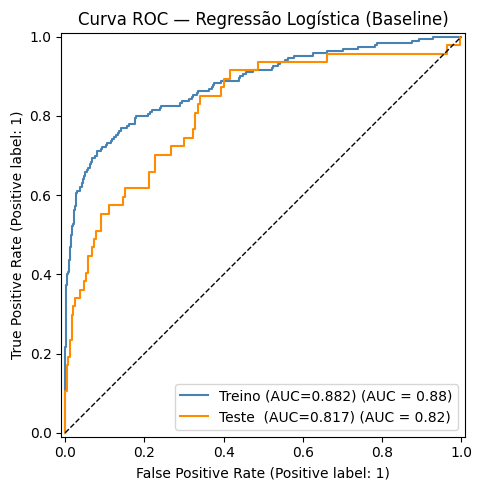

In [11]:
# 8. CURVA ROC — TREINO E TESTE

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(
    r_treino["y"], r_treino["y_proba"],
    name=f"Treino (AUC={r_treino['auc']:.3f})", ax=ax, color="steelblue"
)
RocCurveDisplay.from_predictions(
    r_teste["y"], r_teste["y_proba"],
    name=f"Teste  (AUC={r_teste['auc']:.3f})", ax=ax, color="darkorange"
)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Regressão Logística (Baseline)")
plt.tight_layout()
plt.savefig("roc_treino_vs_teste.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# 9. GERAR PROBABILIDADES DE SAÍDA (dataset completo)
url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
df_completo = pd.read_csv(url)

# Aplicar a mesma preparação de features que fizeste no início
cols_remover = ["Attrition", "OverTime", "Gender", "BusinessTravel", 
                "Department", "EducationField", "JobRole", "MaritalStatus"]
cols_remover = [c for c in cols_remover if c in df_completo.columns]

X_completo = df_completo.drop(columns=cols_remover + ["Attrition_bin"])
X_completo = X_completo.select_dtypes(include=[np.number])

df_risco = df_completo.copy()
df_risco["prob_saida"] = pipeline.predict_proba(X_completo)[:, 1]

print(f"Probabilidades geradas para {len(df_risco)} colaboradores.")
print(df_risco["prob_saida"].describe(percentiles=[.25, .50, .75, .90]).round(4))

Probabilidades geradas para 1470 colaboradores.
count    1470.0000
mean        0.1591
std         0.2222
min         0.0000
25%         0.0132
50%         0.0598
75%         0.2057
90%         0.5180
max         0.9932
Name: prob_saida, dtype: float64


In [13]:
# 10. CLASSIFICAÇÃO EM CATEGORIAS DE RISCO

def classificar_risco(prob):
    if prob < 0.30:
        return "Baixo"
    elif prob <= 0.60:
        return "Medio"
    else:
        return "Alto"

df_risco["nivel_risco"] = df_risco["prob_saida"].apply(classificar_risco)

ORDEM = ["Baixo", "Medio", "Alto"]

contagem    = df_risco["nivel_risco"].value_counts()
percentagem = df_risco["nivel_risco"].value_counts(normalize=True) * 100

print("\n===== DISTRIBUICAO DAS CATEGORIAS DE RISCO =====")
print(f"  {'Categoria':<10}  {'Contagem':>8}  {'Percentagem':>12}")
print(f"  {'-'*34}")
for cat in ORDEM:
    n   = contagem.get(cat, 0)
    pct = percentagem.get(cat, 0.0)
    print(f"  {cat:<10}  {n:>8}  {pct:>11.1f}%")


===== DISTRIBUICAO DAS CATEGORIAS DE RISCO =====
  Categoria   Contagem   Percentagem
  ----------------------------------
  Baixo           1217         82.8%
  Medio            147         10.0%
  Alto             106          7.2%


In [14]:
# 11. ANÁLISE POR CATEGORIA DE RISCO

cols_analise = ["prob_saida", "Attrition_bin"]
for col in ["Age", "MonthlyIncome", "JobLevel", "TotalWorkingYears",
            "OverTime_bin", "SatisfactionIndex", "YearsAtCompany"]:
    if col in df_risco.columns:
        cols_analise.append(col)

print("\n===== PERFIL MEDIO POR CATEGORIA DE RISCO =====")
perfil = df_risco.groupby("nivel_risco")[cols_analise].mean().reindex(ORDEM).round(3)
display(perfil)


===== PERFIL MEDIO POR CATEGORIA DE RISCO =====


,prob_saida,Attrition_bin,Age,MonthlyIncome,JobLevel,TotalWorkingYears,OverTime_bin,SatisfactionIndex,YearsAtCompany
nivel_risco,,,,,,,,,
Baixo,0.071,0.065,37.969,6977.157,2.177,12.175,0.214,2.217,7.604
Medio,0.441,0.449,32.571,4438.803,1.578,7.605,0.605,1.993,4.844
Alto,0.782,0.868,30.962,3920.802,1.443,6.094,0.632,1.811,3.170


In [15]:
# 12. TOP 20 COLABORADORES COM MAIOR RISCO

cols_top = ["prob_saida", "nivel_risco", "Attrition_bin"]
for col in ["Age", "MonthlyIncome", "JobLevel", "OverTime_bin"]:
    if col in df_risco.columns:
        cols_top.append(col)

top20 = df_risco.nlargest(20, "prob_saida")[cols_top].reset_index(drop=True)

print("\n===== TOP 20 — MAIOR PROBABILIDADE DE SAIDA =====")
display(top20)


===== TOP 20 — MAIOR PROBABILIDADE DE SAIDA =====


,prob_saida,nivel_risco,Attrition_bin,Age,MonthlyIncome,JobLevel,OverTime_bin
0,0.993184,Alto,1,26,2340,1,1
1,0.992612,Alto,1,25,1118,1,1
2,0.984904,Alto,1,24,3172,1,1
3,0.981745,Alto,1,18,1878,1,1
4,0.980088,Alto,1,21,2174,1,1
5,0.978946,Alto,1,32,2795,1,1
6,0.960832,Alto,1,19,1675,1,1
7,0.953581,Alto,1,19,2325,1,0
8,0.951764,Alto,1,19,2121,1,1
9,0.950460,Alto,1,27,2863,1,0


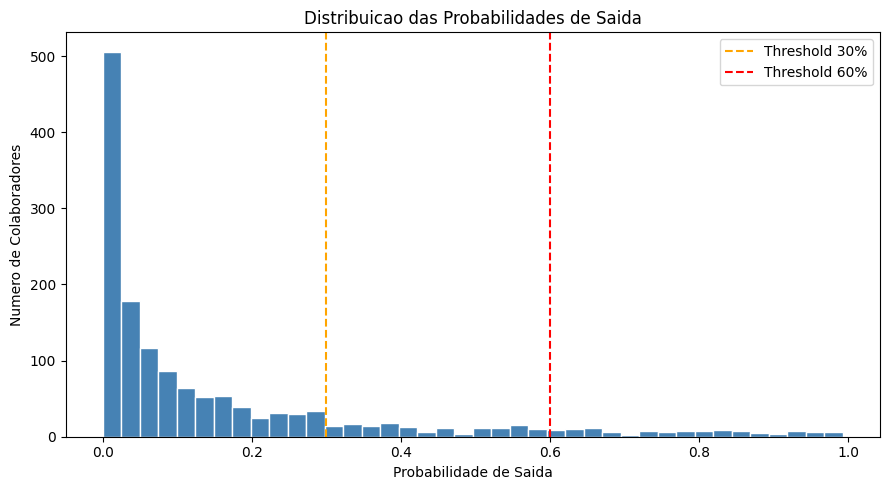

In [16]:
# 13. VISUALIZAÇÕES DO ÍNDICE DE RISCO

# 13.1 Histograma das probabilidades
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df_risco["prob_saida"], bins=40, color="steelblue", edgecolor="white")
ax.axvline(0.30, color="orange", linestyle="--", linewidth=1.5, label="Threshold 30%")
ax.axvline(0.60, color="red",    linestyle="--", linewidth=1.5, label="Threshold 60%")
ax.set_xlabel("Probabilidade de Saida")
ax.set_ylabel("Numero de Colaboradores")
ax.set_title("Distribuicao das Probabilidades de Saida")
ax.legend()
plt.tight_layout()
plt.savefig("distribuicao_probabilidades.png", dpi=150, bbox_inches="tight")
plt.show()

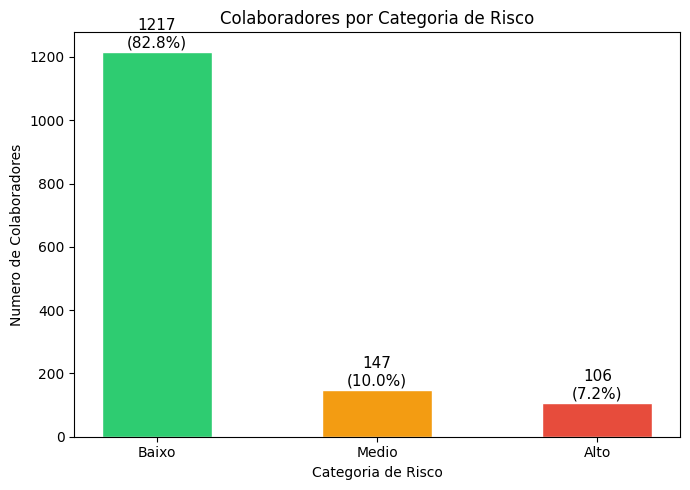

In [17]:
# 13.2 Contagem por categoria
cores = {"Baixo": "#2ecc71", "Medio": "#f39c12", "Alto": "#e74c3c"}

fig, ax = plt.subplots(figsize=(7, 5))
vals = [contagem.get(c, 0) for c in ORDEM]
bars = ax.bar(ORDEM, vals, color=[cores[c] for c in ORDEM], edgecolor="white", width=0.5)
for bar, cat in zip(bars, ORDEM):
    n   = contagem.get(cat, 0)
    pct = percentagem.get(cat, 0.0)
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{n}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=11
    )
ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Numero de Colaboradores")
ax.set_title("Colaboradores por Categoria de Risco")
plt.tight_layout()
plt.savefig("categorias_risco.png", dpi=150, bbox_inches="tight")
plt.show()

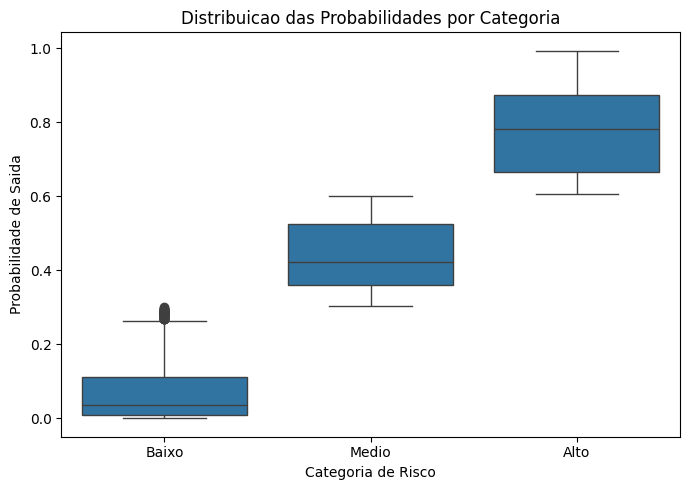

In [18]:
# 13.3 Boxplot por categoria
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df_risco, x="nivel_risco", y="prob_saida", order=ORDEM, ax=ax)
ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Probabilidade de Saida")
ax.set_title("Distribuicao das Probabilidades por Categoria")
plt.tight_layout()
plt.savefig("boxplot_risco.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
# 14. RESUMO FINAL

print("=" * 55)
print("RESUMO — Baseline")
print("=" * 55)
print(f"  Modelo:         Regressao Logistica (parâmetros default)")
print(f"  Colaboradores:  {len(df_risco)}")
print(f"\n  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}")
print(f"  {'-'*32}")
for metrica, nome in [("acc","Accuracy"), ("precision","Precision"),
                       ("recall","Recall"), ("f1","F1-Score"), ("auc","AUC-ROC")]:
    print(f"  {nome:<12}  {r_treino[metrica]:>8.4f}  {r_teste[metrica]:>8.4f}")
print(f"\n  Baixo risco:    prob < 30%  -> {contagem.get('Baixo', 0)} colaboradores")
print(f"  Risco medio:    30% - 60%   -> {contagem.get('Medio', 0)} colaboradores")
print(f"  Alto risco:     prob > 60%  -> {contagem.get('Alto', 0)} colaboradores")
print("=" * 55)

RESUMO — Baseline
  Modelo:         Regressao Logistica (parâmetros default)
  Colaboradores:  1470

  Métrica         Treino     Teste
  --------------------------------
  Accuracy        0.9065    0.8639
  Precision       0.8175    0.6296
  Recall          0.5421    0.3617
  F1-Score        0.6519    0.4595
  AUC-ROC         0.8819    0.8170

  Baixo risco:    prob < 30%  -> 1217 colaboradores
  Risco medio:    30% - 60%   -> 147 colaboradores
  Alto risco:     prob > 60%  -> 106 colaboradores


#  Treino e Avaliação Comparativa do Desempenho de Modelos Candidatos


## Índice de Risco - Naive Bayes
Modelo Naive Bayes com StandardScaler e classificação de risco.

In [20]:
# 15. TREINO — NAIVE BAYES
pipeline_nb = Pipeline([
    ("scaler", StandardScaler()),
    ("nb", GaussianNB())
])

pipeline_nb.fit(X_train, y_train)
print("Modelo Naive Bayes treinado.")

Modelo Naive Bayes treinado.


In [21]:
# 16. AVALIAÇÃO NO CONJUNTO DE TREINO E TESTE (NAIVE BAYES)

def avaliar_modelo(pipeline, X, y, nome_conjunto):
    y_pred       = pipeline.predict(X)
    y_pred_proba = pipeline.predict_proba(X)[:, 1]

    acc       = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall    = recall_score(y, y_pred)
    f1        = f1_score(y, y_pred)
    auc       = roc_auc_score(y, y_pred_proba)

    print(f"===== METRICAS — {nome_conjunto} =====")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}")
    print()
    print(classification_report(y, y_pred, target_names=["Permaneceu", "Saiu"]))

    return {
        "conjunto":  nome_conjunto,
        "acc":       acc,
        "precision": precision,
        "recall":    recall,
        "f1":        f1,
        "auc":       auc,
        "y":         y,
        "y_proba":   y_pred_proba
    }

In [22]:
# 16.1 TREINO
resultados_treino_nb = avaliar_modelo(pipeline_nb, X_train, y_train, "Treino")

===== METRICAS — Treino =====
  F1-Score:  0.4294
  Precision: 0.3004
  Recall:    0.7526
  AUC-ROC:   0.7768

              precision    recall  f1-score   support

  Permaneceu       0.93      0.66      0.77       986
        Saiu       0.30      0.75      0.43       190

    accuracy                           0.68      1176
   macro avg       0.62      0.71      0.60      1176
weighted avg       0.83      0.68      0.72      1176



In [23]:
# 16.2 TESTE
resultados_teste_nb  = avaliar_modelo(pipeline_nb, X_test,  y_test,  "Teste")

===== METRICAS — Teste =====
  F1-Score:  0.3681
  Precision: 0.2586
  Recall:    0.6383
  AUC-ROC:   0.6831

              precision    recall  f1-score   support

  Permaneceu       0.90      0.65      0.76       247
        Saiu       0.26      0.64      0.37        47

    accuracy                           0.65       294
   macro avg       0.58      0.65      0.56       294
weighted avg       0.80      0.65      0.70       294



In [24]:
# 17. COMPARAÇÃO TREINO vs TESTE (NAIVE BAYES)

print("===== COMPARAÇÃO TREINO vs TESTE (NAIVE BAYES) =====")
print(f"  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}  {'Diferença':>10}")
print(f"  {'-'*44}")

# Iterar sobre as métricas guardadas no dicionário
for metrica in ["acc", "precision", "recall", "f1", "auc"]:
    val_treino = resultados_treino_nb[metrica]
    val_teste  = resultados_teste_nb[metrica]
    diff       = val_treino - val_teste
    
    # Formatação do nome da métrica
    nome = metrica.upper() if metrica != "acc" else "Accuracy"
    
    print(f"  {nome:<12}  {val_treino:>8.4f}  {val_teste:>8.4f}  {diff:>+10.4f}")

# Validação automática de Overfitting focada no F1-Score
diff_f1_nb = resultados_treino_nb["f1"] - resultados_teste_nb["f1"]

print() # Linha em branco para limpeza visual
if diff_f1_nb > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== COMPARAÇÃO TREINO vs TESTE (NAIVE BAYES) =====
  Métrica         Treino     Teste   Diferença
  --------------------------------------------
  Accuracy        0.6769    0.6497     +0.0272
  PRECISION       0.3004    0.2586     +0.0418
  RECALL          0.7526    0.6383     +0.1143
  F1              0.4294    0.3681     +0.0613
  AUC             0.7768    0.6831     +0.0938

  --> Sem sinais evidentes de overfitting.


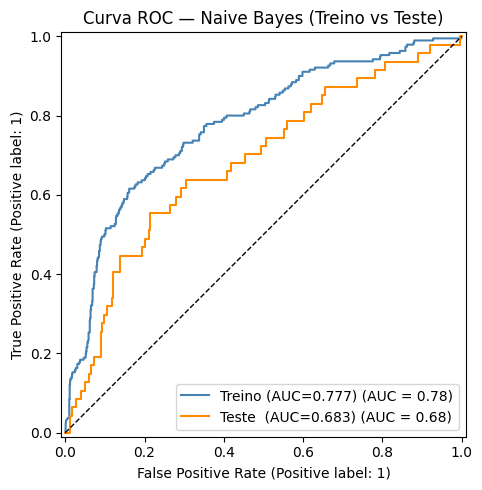

In [25]:
# 18. CURVAS ROC SOBREPOSTAS (NAIVE BAYES)

fig, ax = plt.subplots(figsize=(7, 5))

# Curva de Treino
RocCurveDisplay.from_predictions(
    resultados_treino_nb["y"], resultados_treino_nb["y_proba"],
    name=f"Treino (AUC={resultados_treino_nb['auc']:.3f})", ax=ax, color="steelblue"
)

# Curva de Teste
RocCurveDisplay.from_predictions(
    resultados_teste_nb["y"], resultados_teste_nb["y_proba"],
    name=f"Teste  (AUC={resultados_teste_nb['auc']:.3f})", ax=ax, color="darkorange"
)

# Linha de referência (o "acaso")
ax.plot([0, 1], [0, 1], "k--", lw=1)

ax.set_title("Curva ROC — Naive Bayes (Treino vs Teste)")
plt.tight_layout()
plt.savefig("roc_treino_vs_teste_nb.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
# 19. GERAR PROBABILIDADES DE SAÍDA (dataset completo - NAIVE BAYES)

url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
df_completo = pd.read_csv(url)

# Aplicar a mesma preparação de features
cols_remover = ["Attrition", "OverTime", "Gender", "BusinessTravel", 
                "Department", "EducationField", "JobRole", "MaritalStatus"]
cols_remover = [c for c in cols_remover if c in df_completo.columns]

# Adicionei errors='ignore' para evitar erros caso a Attrition_bin não esteja no CSV
X_completo = df_completo.drop(columns=cols_remover + ["Attrition_bin"], errors='ignore')
X_completo = X_completo.select_dtypes(include=[np.number])

# Usamos df_risco_nb para não sobrescrever o teu trabalho da Regressão Logística
df_risco_nb = df_completo.copy()

# A MUDANÇA PRINCIPAL: Chamar o pipeline do Naive Bayes
df_risco_nb["prob_saida"] = pipeline_nb.predict_proba(X_completo)[:, 1]

print(f"Probabilidades geradas para {len(df_risco_nb)} colaboradores (Naive Bayes).")
print(df_risco_nb["prob_saida"].describe(percentiles=[.25, .50, .75, .90]).round(4))

Probabilidades geradas para 1470 colaboradores (Naive Bayes).
count    1470.0000
mean        0.3936
std         0.4290
min         0.0000
25%         0.0000
50%         0.1272
75%         0.9141
90%         0.9984
max         1.0000
Name: prob_saida, dtype: float64


In [27]:
# 20. CLASSIFICAÇÃO EM CATEGORIAS DE RISCO (NAIVE BAYES)

def classificar_risco(prob):
    if prob < 0.30:
        return "Baixo"
    elif prob <= 0.60:
        return "Medio"
    else:
        return "Alto"

# Aplicar a função ao DataFrame do Naive Bayes
df_risco_nb["nivel_risco"] = df_risco_nb["prob_saida"].apply(classificar_risco)

ORDEM = ["Baixo", "Medio", "Alto"]

contagem_nb    = df_risco_nb["nivel_risco"].value_counts()
percentagem_nb = df_risco_nb["nivel_risco"].value_counts(normalize=True) * 100

print("\n===== DISTRIBUICAO DAS CATEGORIAS DE RISCO (NAIVE BAYES) =====")
print(f"  {'Categoria':<10}  {'Contagem':>8}  {'Percentagem':>12}")
print(f"  {'-'*34}")
for cat in ORDEM:
    n   = contagem_nb.get(cat, 0)
    pct = percentagem_nb.get(cat, 0.0)
    print(f"  {cat:<10}  {n:>8}  {pct:>11.1f}%")


===== DISTRIBUICAO DAS CATEGORIAS DE RISCO (NAIVE BAYES) =====
  Categoria   Contagem   Percentagem
  ----------------------------------
  Baixo            811         55.2%
  Medio            105          7.1%
  Alto             554         37.7%


In [28]:
# 21. ANÁLISE POR CATEGORIA DE RISCO (NAIVE BAYES)

cols_analise = ["prob_saida", "Attrition_bin"]
# Adicionamos as variáveis de negócio para ver a "cara" de cada nível de risco
for col in ["Age", "MonthlyIncome", "JobLevel", "TotalWorkingYears", 
            "OverTime_bin", "SatisfactionIndex", "YearsAtCompany"]:
    if col in df_risco_nb.columns:
        cols_analise.append(col)

print("\n===== PERFIL MÉDIO POR CATEGORIA DE RISCO (NAIVE BAYES) =====")
perfil_nb = df_risco_nb.groupby("nivel_risco")[cols_analise].mean().reindex(ORDEM).round(3)
display(perfil_nb)


===== PERFIL MÉDIO POR CATEGORIA DE RISCO (NAIVE BAYES) =====


,prob_saida,Attrition_bin,Age,MonthlyIncome,JobLevel,TotalWorkingYears,OverTime_bin,SatisfactionIndex,YearsAtCompany
nivel_risco,,,,,,,,,
Baixo,0.029,0.072,39.624,8597.938,2.580,14.649,0.249,2.243,9.238
Medio,0.455,0.095,36.343,4114.543,1.486,9.267,0.276,2.171,6.219
Alto,0.916,0.305,33.081,3888.726,1.419,6.729,0.334,2.051,3.894


In [29]:
# 22. TOP 20 COLABORADORES COM MAIOR RISCO (NAIVE BAYES)

cols_top = ["prob_saida", "nivel_risco", "Attrition_bin"]
for col in ["Age", "MonthlyIncome", "JobLevel", "OverTime_bin"]:
    if col in df_risco_nb.columns:
        cols_top.append(col)

top20_nb = df_risco_nb.nlargest(20, "prob_saida")[cols_top].reset_index(drop=True)

print("\n===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (NAIVE BAYES) =====")
display(top20_nb)


===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (NAIVE BAYES) =====


,prob_saida,nivel_risco,Attrition_bin,Age,MonthlyIncome,JobLevel,OverTime_bin
0,1.0,Alto,1,24,1555,1,0
1,1.0,Alto,0,36,3886,2,0
2,1.0,Alto,1,27,2863,1,0
3,1.0,Alto,0,31,6410,2,0
4,1.0,Alto,1,31,2956,1,0
5,1.0,Alto,1,29,2335,1,1
6,1.0,Alto,1,37,2073,1,1
7,1.0,Alto,1,30,2180,1,0
8,1.0,Alto,0,25,2187,1,0
9,1.0,Alto,0,38,6077,2,0


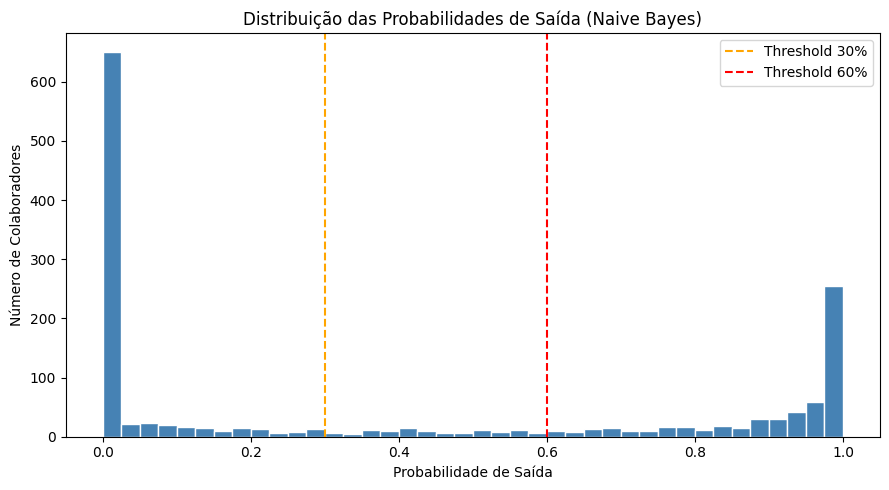

In [30]:
# 23. VISUALIZAÇÕES DO ÍNDICE DE RISCO (NAIVE BAYES)

# 23.1 Histograma das probabilidades
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df_risco_nb["prob_saida"], bins=40, color="steelblue", edgecolor="white")
ax.axvline(0.30, color="orange", linestyle="--", linewidth=1.5, label="Threshold 30%")
ax.axvline(0.60, color="red",    linestyle="--", linewidth=1.5, label="Threshold 60%")
ax.set_xlabel("Probabilidade de Saída")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Distribuição das Probabilidades de Saída (Naive Bayes)")
ax.legend()
plt.tight_layout()
plt.savefig("distribuicao_probabilidades_nb.png", dpi=150, bbox_inches="tight")
plt.show()

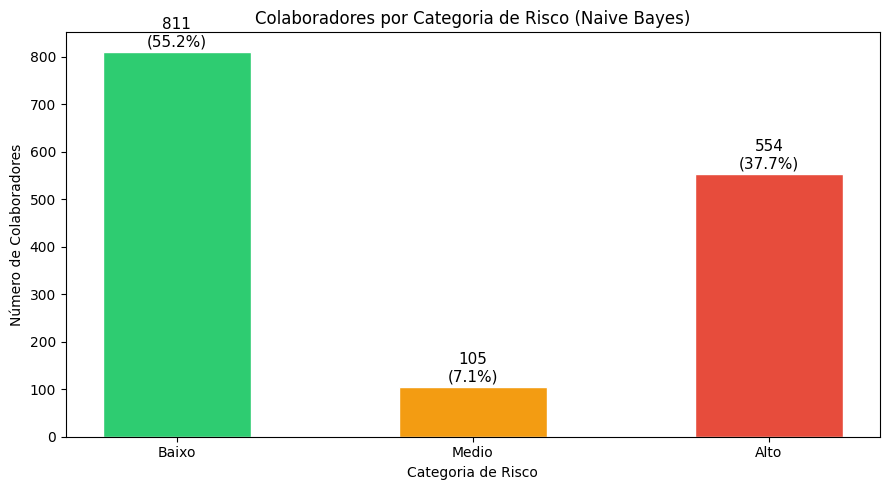

In [31]:
# 23.2 Contagem por categoria (NAIVE BAYES)
cores = {"Baixo": "#2ecc71", "Medio": "#f39c12", "Alto": "#e74c3c"}
fig, ax = plt.subplots(figsize=(9, 5))
vals = [contagem_nb.get(c, 0) for c in ORDEM]
bars = ax.bar(ORDEM, vals, color=[cores[c] for c in ORDEM], edgecolor="white", width=0.5)

for bar, cat in zip(bars, ORDEM):
    n   = contagem_nb.get(cat, 0)
    pct = percentagem_nb.get(cat, 0.0)
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5, 
        f"{n}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=11
    )

ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Colaboradores por Categoria de Risco (Naive Bayes)")
plt.tight_layout()

plt.savefig("categorias_risco_nb.png", dpi=150, bbox_inches="tight")
plt.show()

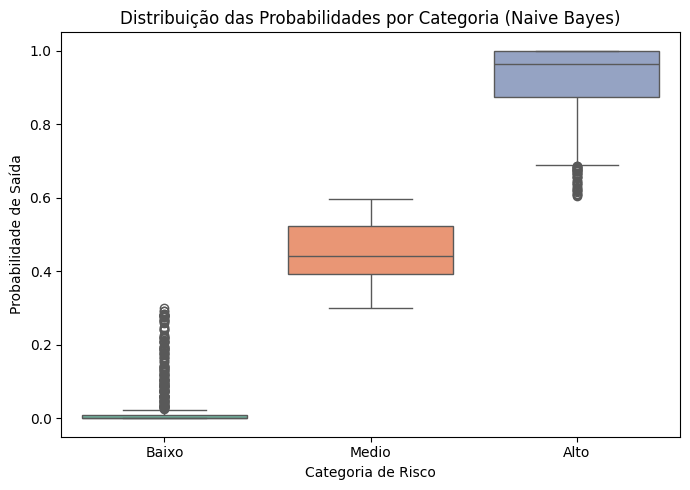

In [32]:
# 23.3 Boxplot por categoria (NAIVE BAYES)
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df_risco_nb, x="nivel_risco", y="prob_saida", order=ORDEM, ax=ax, palette="Set2")
ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Probabilidade de Saída")
ax.set_title("Distribuição das Probabilidades por Categoria (Naive Bayes)")
plt.tight_layout()
plt.savefig("boxplot_risco_nb.png", dpi=150, bbox_inches="tight")
plt.show()

In [33]:
# 24. RESUMO FINAL (NAIVE BAYES)

print("=" * 55)
print("RESUMO — Naive Bayes")
print("=" * 55)
print(f"  Modelo:         Naive Bayes (parâmetros default)")
print(f"  Colaboradores:  {len(df_risco_nb)}")
print(f"\n  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}")
print(f"  {'-'*32}")
for metrica, nome in [("acc","Accuracy"), ("precision","Precision"),
                       ("recall","Recall"), ("f1","F1-Score"), ("auc","AUC-ROC")]:
    print(f"  {nome:<12}  {resultados_treino_nb[metrica]:>8.4f}  {resultados_teste_nb[metrica]:>8.4f}")
print(f"\n  Baixo risco:    prob < 30%  -> {contagem_nb.get('Baixo', 0)} colaboradores")
print(f"  Risco medio:    30% - 60%   -> {contagem_nb.get('Medio', 0)} colaboradores")
print(f"  Alto risco:     prob > 60%  -> {contagem_nb.get('Alto', 0)} colaboradores")
print("=" * 55)

RESUMO — Naive Bayes
  Modelo:         Naive Bayes (parâmetros default)
  Colaboradores:  1470

  Métrica         Treino     Teste
  --------------------------------
  Accuracy        0.6769    0.6497
  Precision       0.3004    0.2586
  Recall          0.7526    0.6383
  F1-Score        0.4294    0.3681
  AUC-ROC         0.7768    0.6831

  Baixo risco:    prob < 30%  -> 811 colaboradores
  Risco medio:    30% - 60%   -> 105 colaboradores
  Alto risco:     prob > 60%  -> 554 colaboradores


## Índice de Risco - LDA (Linear Discriminant Analysis)
Modelo LDA com StandardScaler e classificação de risco.

In [34]:
# 25. TREINO — LDA (LINEAR DISCRIMINANT ANALYSIS)
pipeline_lda = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis())
])

pipeline_lda.fit(X_train, y_train)
print("Modelo LDA treinado.")

Modelo LDA treinado.


In [35]:
# 26. AVALIAÇÃO NO CONJUNTO DE TREINO E TESTE (LDA)

def avaliar_modelo(pipeline, X, y, nome_conjunto):
    y_pred       = pipeline.predict(X)
    y_pred_proba = pipeline.predict_proba(X)[:, 1]

    acc       = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall    = recall_score(y, y_pred)
    f1        = f1_score(y, y_pred)
    auc       = roc_auc_score(y, y_pred_proba)

    print(f"===== METRICAS — {nome_conjunto} =====")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}")
    print()
    print(classification_report(y, y_pred, target_names=["Permaneceu", "Saiu"]))

    return {
        "conjunto":  nome_conjunto,
        "acc":       acc,
        "precision": precision,
        "recall":    recall,
        "f1":        f1,
        "auc":       auc,
        "y":         y,
        "y_proba":   y_pred_proba
    }

In [36]:
# 26.1 TREINO
resultados_treino_lda = avaliar_modelo(pipeline_lda, X_train, y_train, "Treino")

===== METRICAS — Treino =====
  F1-Score:  0.6454
  Precision: 0.8211
  Recall:    0.5316
  AUC-ROC:   0.8735

              precision    recall  f1-score   support

  Permaneceu       0.92      0.98      0.95       986
        Saiu       0.82      0.53      0.65       190

    accuracy                           0.91      1176
   macro avg       0.87      0.75      0.80      1176
weighted avg       0.90      0.91      0.90      1176



In [37]:
# 26.2 TESTE 
resultados_teste_lda  = avaliar_modelo(pipeline_lda, X_test,  y_test,  "Teste")

===== METRICAS — Teste =====
  F1-Score:  0.4167
  Precision: 0.6000
  Recall:    0.3191
  AUC-ROC:   0.8099

              precision    recall  f1-score   support

  Permaneceu       0.88      0.96      0.92       247
        Saiu       0.60      0.32      0.42        47

    accuracy                           0.86       294
   macro avg       0.74      0.64      0.67       294
weighted avg       0.84      0.86      0.84       294



In [38]:
# 27. COMPARAÇÃO TREINO vs TESTE (LDA)

print("===== COMPARAÇÃO TREINO vs TESTE (LDA) =====")
print(f"  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}  {'Diferença':>10}")
print(f"  {'-'*44}")

# Iterar sobre as métricas guardadas no dicionário
for metrica in ["acc", "precision", "recall", "f1", "auc"]:
    val_treino = resultados_treino_lda[metrica]
    val_teste  = resultados_teste_lda[metrica]
    diff       = val_treino - val_teste
    
    # Formatação do nome da métrica
    nome = metrica.upper() if metrica != "acc" else "Accuracy"
    
    print(f"  {nome:<12}  {val_treino:>8.4f}  {val_teste:>8.4f}  {diff:>+10.4f}")

# Validação automática de Overfitting focada no F1-Score
diff_f1_lda = resultados_treino_lda["f1"] - resultados_teste_lda["f1"]

print() # Linha em branco para limpeza visual
if diff_f1_lda > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== COMPARAÇÃO TREINO vs TESTE (LDA) =====
  Métrica         Treino     Teste   Diferença
  --------------------------------------------
  Accuracy        0.9056    0.8571     +0.0485
  PRECISION       0.8211    0.6000     +0.2211
  RECALL          0.5316    0.3191     +0.2124
  F1              0.6454    0.4167     +0.2287
  AUC             0.8735    0.8099     +0.0636

  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


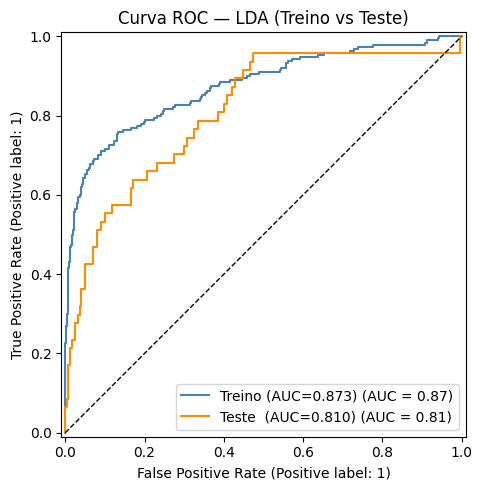

In [39]:
# 28. CURVAS ROC SOBREPOSTAS (LDA)
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 5))

# Curva de Treino
RocCurveDisplay.from_predictions(
    resultados_treino_lda["y"], resultados_treino_lda["y_proba"],
    name=f"Treino (AUC={resultados_treino_lda['auc']:.3f})", ax=ax, color="steelblue"
)

# Curva de Teste
RocCurveDisplay.from_predictions(
    resultados_teste_lda["y"], resultados_teste_lda["y_proba"],
    name=f"Teste  (AUC={resultados_teste_lda['auc']:.3f})", ax=ax, color="darkorange"
)

# Linha de referência (o "acaso")
ax.plot([0, 1], [0, 1], "k--", lw=1)

ax.set_title("Curva ROC — LDA (Treino vs Teste)")
plt.tight_layout()
plt.savefig("roc_treino_vs_teste_lda.png", dpi=150, bbox_inches="tight")
plt.show()

In [40]:
# 29. GERAR PROBABILIDADES DE SAÍDA (dataset completo - LDA)

url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
df_completo = pd.read_csv(url)

# Aplicar a mesma preparação de features
cols_remover = ["Attrition", "OverTime", "Gender", "BusinessTravel", 
                "Department", "EducationField", "JobRole", "MaritalStatus"]
cols_remover = [c for c in cols_remover if c in df_completo.columns]

# Evitar erros caso a Attrition_bin não esteja no CSV
X_completo = df_completo.drop(columns=cols_remover + ["Attrition_bin"], errors='ignore')
X_completo = X_completo.select_dtypes(include=[np.number])

# Usamos df_risco_lda para não sobrescrever o teu trabalho anterior
df_risco_lda = df_completo.copy()

# A MUDANÇA PRINCIPAL: Chamar o pipeline do LDA
df_risco_lda["prob_saida"] = pipeline_lda.predict_proba(X_completo)[:, 1]

print(f"Probabilidades geradas para {len(df_risco_lda)} colaboradores (LDA).")
print(df_risco_lda["prob_saida"].describe(percentiles=[.25, .50, .75, .90]).round(4))

Probabilidades geradas para 1470 colaboradores (LDA).
count    1470.0000
mean        0.1567
std         0.2227
min         0.0000
25%         0.0157
50%         0.0586
75%         0.1902
90%         0.5010
max         0.9964
Name: prob_saida, dtype: float64


In [41]:
# 30. CLASSIFICAÇÃO EM CATEGORIAS DE RISCO (LDA)

def classificar_risco(prob):
    if prob < 0.30:
        return "Baixo"
    elif prob <= 0.60:
        return "Medio"
    else:
        return "Alto"

# Aplicar a função ao DataFrame do LDA
df_risco_lda["nivel_risco"] = df_risco_lda["prob_saida"].apply(classificar_risco)

ORDEM = ["Baixo", "Medio", "Alto"]

contagem_lda    = df_risco_lda["nivel_risco"].value_counts()
percentagem_lda = df_risco_lda["nivel_risco"].value_counts(normalize=True) * 100

print("\n===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO (LDA) =====")
print(f"  {'Categoria':<10}  {'Contagem':>8}  {'Percentagem':>12}")
print(f"  {'-'*34}")
for cat in ORDEM:
    n   = contagem_lda.get(cat, 0)
    pct = percentagem_lda.get(cat, 0.0)
    print(f"  {cat:<10}  {n:>8}  {pct:>11.1f}%")


===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO (LDA) =====
  Categoria   Contagem   Percentagem
  ----------------------------------
  Baixo           1214         82.6%
  Medio            154         10.5%
  Alto             102          6.9%


In [42]:
# 31. ANÁLISE POR CATEGORIA DE RISCO (LDA)

cols_analise = ["prob_saida", "Attrition_bin"]
# Adicionamos as variáveis de negócio para ver a "cara" de cada nível de risco
for col in ["Age", "MonthlyIncome", "JobLevel", "TotalWorkingYears", 
            "OverTime_bin", "SatisfactionIndex", "YearsAtCompany"]:
    if col in df_risco_lda.columns:
        cols_analise.append(col)

print("\n===== PERFIL MÉDIO POR CATEGORIA DE RISCO (LDA) =====")
perfil_lda = df_risco_lda.groupby("nivel_risco")[cols_analise].mean().reindex(ORDEM).round(3)
display(perfil_lda)


===== PERFIL MÉDIO POR CATEGORIA DE RISCO (LDA) =====


,prob_saida,Attrition_bin,Age,MonthlyIncome,JobLevel,TotalWorkingYears,OverTime_bin,SatisfactionIndex,YearsAtCompany
nivel_risco,,,,,,,,,
Baixo,0.067,0.066,38.002,7008.591,2.186,12.188,0.220,2.212,7.638
Medio,0.435,0.435,32.662,4518.448,1.584,7.916,0.532,1.994,4.844
Alto,0.800,0.882,30.529,3480.775,1.333,5.549,0.657,1.873,2.775


In [43]:
# 32. TOP 20 COLABORADORES COM MAIOR RISCO (LDA)

cols_top = ["prob_saida", "nivel_risco", "Attrition_bin"]
for col in ["Age", "MonthlyIncome", "JobLevel", "OverTime_bin"]:
    if col in df_risco_lda.columns:
        cols_top.append(col)

top20_lda = df_risco_lda.nlargest(20, "prob_saida")[cols_top].reset_index(drop=True)

print("\n===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (LDA) =====")
display(top20_lda)


===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (LDA) =====


,prob_saida,nivel_risco,Attrition_bin,Age,MonthlyIncome,JobLevel,OverTime_bin
0,0.996399,Alto,1,25,1118,1,1
1,0.994332,Alto,1,26,2340,1,1
2,0.991633,Alto,1,18,1878,1,1
3,0.987326,Alto,1,21,2174,1,1
4,0.983142,Alto,1,24,3172,1,1
5,0.981588,Alto,1,19,1675,1,1
6,0.975440,Alto,1,19,2121,1,1
7,0.975315,Alto,1,18,1569,1,1
8,0.975195,Alto,1,32,2795,1,1
9,0.974293,Alto,1,19,2325,1,0


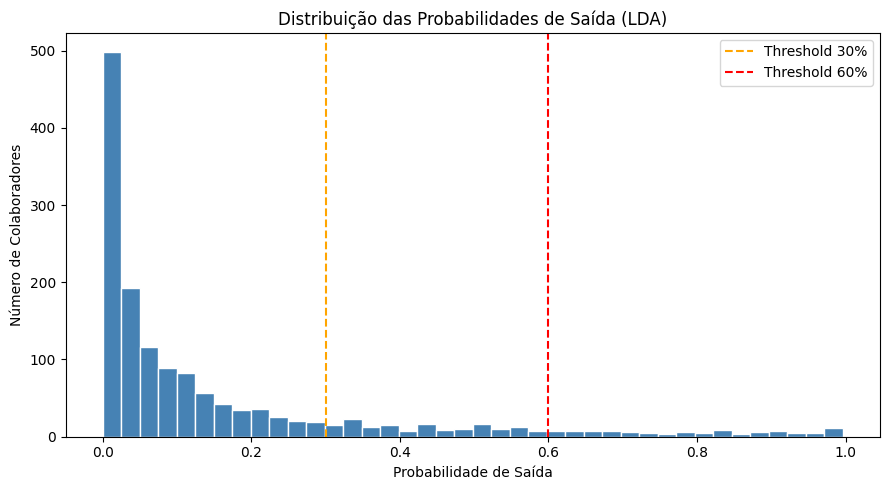

In [44]:
# 33. VISUALIZAÇÕES DO ÍNDICE DE RISCO (LDA)

# 33.1 Histograma das probabilidades
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df_risco_lda["prob_saida"], bins=40, color="steelblue", edgecolor="white")
ax.axvline(0.30, color="orange", linestyle="--", linewidth=1.5, label="Threshold 30%")
ax.axvline(0.60, color="red",    linestyle="--", linewidth=1.5, label="Threshold 60%")
ax.set_xlabel("Probabilidade de Saída")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Distribuição das Probabilidades de Saída (LDA)")
ax.legend()
plt.tight_layout()
plt.savefig("distribuicao_probabilidades_lda.png", dpi=150, bbox_inches="tight")
plt.show()

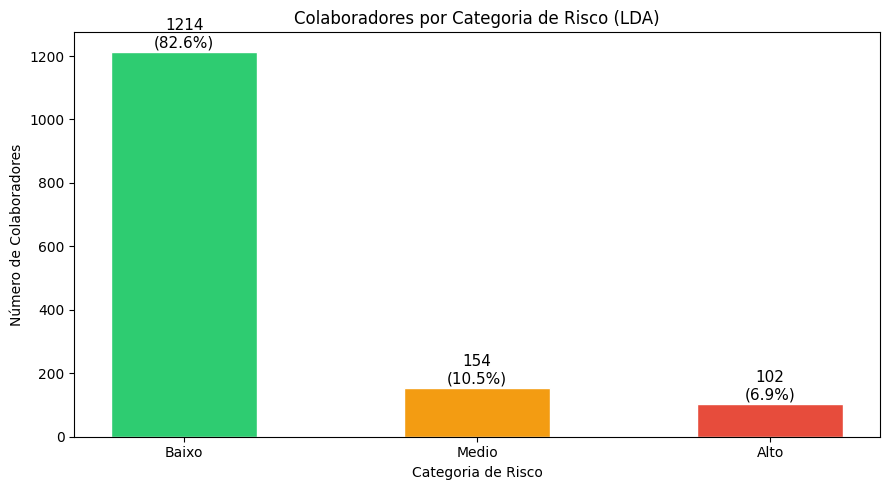

In [45]:
# 33.2 Contagem por categoria (LDA)
cores = {"Baixo": "#2ecc71", "Medio": "#f39c12", "Alto": "#e74c3c"}
fig, ax = plt.subplots(figsize=(9, 5))
vals = [contagem_lda.get(c, 0) for c in ORDEM]
bars = ax.bar(ORDEM, vals, color=[cores[c] for c in ORDEM], edgecolor="white", width=0.5)

for bar, cat in zip(bars, ORDEM):
    n   = contagem_lda.get(cat, 0)
    pct = percentagem_lda.get(cat, 0.0)
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5, 
        f"{n}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=11
    )

ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Colaboradores por Categoria de Risco (LDA)")
plt.tight_layout()
plt.savefig("categorias_risco_lda.png", dpi=150, bbox_inches="tight")
plt.show()

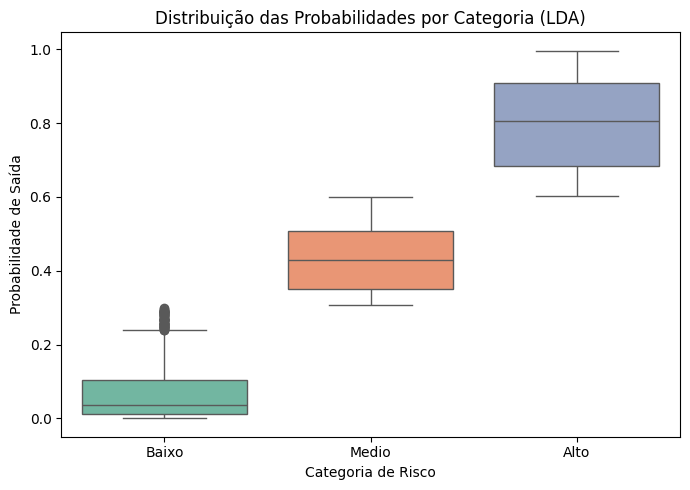

In [46]:
# 33.3 Boxplot por categoria (LDA)
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df_risco_lda, x="nivel_risco", y="prob_saida", order=ORDEM, ax=ax, palette="Set2")
ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Probabilidade de Saída")
ax.set_title("Distribuição das Probabilidades por Categoria (LDA)")
plt.tight_layout()
plt.savefig("boxplot_risco_lda.png", dpi=150, bbox_inches="tight")
plt.show()

In [47]:
# 34. RESUMO FINAL (LDA)

print("=" * 55)
print("RESUMO — LDA")
print("=" * 55)
print(f"  Modelo:         LDA (parâmetros default)")
print(f"  Colaboradores:  {len(df_risco_lda)}")
print(f"\n  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}")
print(f"  {'-'*32}")
for metrica, nome in [("acc","Accuracy"), ("precision","Precision"),
                       ("recall","Recall"), ("f1","F1-Score"), ("auc","AUC-ROC")]:
    print(f"  {nome:<12}  {resultados_treino_lda[metrica]:>8.4f}  {resultados_teste_lda[metrica]:>8.4f}")
print(f"\n  Baixo risco:    prob < 30%  -> {contagem_lda.get('Baixo', 0)} colaboradores")
print(f"  Risco medio:    30% - 60%   -> {contagem_lda.get('Medio', 0)} colaboradores")
print(f"  Alto risco:     prob > 60%  -> {contagem_lda.get('Alto', 0)} colaboradores")
print("=" * 55)

RESUMO — LDA
  Modelo:         LDA (parâmetros default)
  Colaboradores:  1470

  Métrica         Treino     Teste
  --------------------------------
  Accuracy        0.9056    0.8571
  Precision       0.8211    0.6000
  Recall          0.5316    0.3191
  F1-Score        0.6454    0.4167
  AUC-ROC         0.8735    0.8099

  Baixo risco:    prob < 30%  -> 1214 colaboradores
  Risco medio:    30% - 60%   -> 154 colaboradores
  Alto risco:     prob > 60%  -> 102 colaboradores


## Índice de Risco - KNN (K-NEAREST NEIGHBORS)
Modelo KNN com StandardScaler e classificação de risco.

In [48]:
# 35. TREINO — KNN (K-NEAREST NEIGHBORS)
pipeline_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier()) # Vai usar os parâmetros default (ex: n_neighbors=5)
])

pipeline_knn.fit(X_train, y_train)
print("Modelo KNN treinado.")

Modelo KNN treinado.


In [49]:
# 36. AVALIAÇÃO NO CONJUNTO DE TREINO E TESTE (KNN)
def avaliar_modelo(pipeline, X, y, nome_conjunto):
    y_pred       = pipeline.predict(X)
    y_pred_proba = pipeline.predict_proba(X)[:, 1]

    acc       = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall    = recall_score(y, y_pred)
    f1        = f1_score(y, y_pred)
    auc       = roc_auc_score(y, y_pred_proba)

    print(f"===== METRICAS — {nome_conjunto} =====")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}")
    print()
    print(classification_report(y, y_pred, target_names=["Permaneceu", "Saiu"]))

    return {
        "conjunto":  nome_conjunto,
        "acc":       acc,
        "precision": precision,
        "recall":    recall,
        "f1":        f1,
        "auc":       auc,
        "y":         y,
        "y_proba":   y_pred_proba
    }

In [50]:
# 36.1 TREINO
resultados_treino_knn = avaliar_modelo(pipeline_knn, X_train, y_train, "Treino")

===== METRICAS — Treino =====
  F1-Score:  0.4223
  Precision: 0.8689
  Recall:    0.2789
  AUC-ROC:   0.9163

              precision    recall  f1-score   support

  Permaneceu       0.88      0.99      0.93       986
        Saiu       0.87      0.28      0.42       190

    accuracy                           0.88      1176
   macro avg       0.87      0.64      0.68      1176
weighted avg       0.88      0.88      0.85      1176



In [51]:
# 36.2 TESTE
resultados_teste_knn  = avaliar_modelo(pipeline_knn, X_test,  y_test,  "Teste")

===== METRICAS — Teste =====
  F1-Score:  0.1724
  Precision: 0.4545
  Recall:    0.1064
  AUC-ROC:   0.6464

              precision    recall  f1-score   support

  Permaneceu       0.85      0.98      0.91       247
        Saiu       0.45      0.11      0.17        47

    accuracy                           0.84       294
   macro avg       0.65      0.54      0.54       294
weighted avg       0.79      0.84      0.79       294



In [52]:
# 37. COMPARAÇÃO TREINO vs TESTE (KNN)

print("===== COMPARAÇÃO TREINO vs TESTE (KNN) =====")
print(f"  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}  {'Diferença':>10}")
print(f"  {'-'*44}")

# Iterar sobre as métricas guardadas no dicionário
for metrica in ["acc", "precision", "recall", "f1", "auc"]:
    val_treino = resultados_treino_knn[metrica]
    val_teste  = resultados_teste_knn[metrica]
    diff       = val_treino - val_teste
    
    # Formatação do nome da métrica
    nome = metrica.upper() if metrica != "acc" else "Accuracy"
    
    print(f"  {nome:<12}  {val_treino:>8.4f}  {val_teste:>8.4f}  {diff:>+10.4f}")

# Validação automática de Overfitting focada no F1-Score
diff_f1_knn = resultados_treino_knn["f1"] - resultados_teste_knn["f1"]

print() # Linha em branco para limpeza visual
if diff_f1_knn > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== COMPARAÇÃO TREINO vs TESTE (KNN) =====
  Métrica         Treino     Teste   Diferença
  --------------------------------------------
  Accuracy        0.8767    0.8367     +0.0400
  PRECISION       0.8689    0.4545     +0.4143
  RECALL          0.2789    0.1064     +0.1726
  F1              0.4223    0.1724     +0.2499
  AUC             0.9163    0.6464     +0.2699

  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


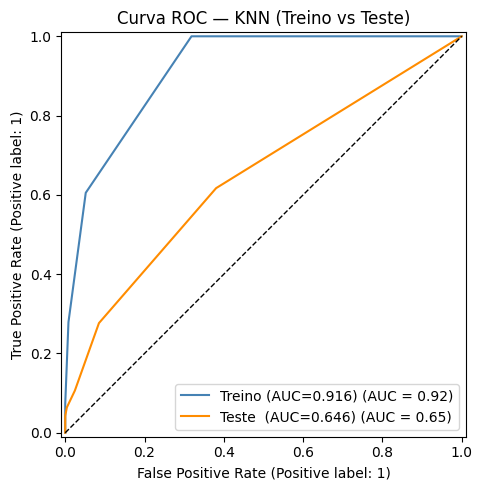

In [53]:
# 38. CURVAS ROC SOBREPOSTAS (KNN)
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 5))

# Curva de Treino
RocCurveDisplay.from_predictions(
    resultados_treino_knn["y"], resultados_treino_knn["y_proba"],
    name=f"Treino (AUC={resultados_treino_knn['auc']:.3f})", ax=ax, color="steelblue"
)

# Curva de Teste
RocCurveDisplay.from_predictions(
    resultados_teste_knn["y"], resultados_teste_knn["y_proba"],
    name=f"Teste  (AUC={resultados_teste_knn['auc']:.3f})", ax=ax, color="darkorange"
)

# Linha de referência (o "acaso")
ax.plot([0, 1], [0, 1], "k--", lw=1)

ax.set_title("Curva ROC — KNN (Treino vs Teste)")
plt.tight_layout()
plt.savefig("roc_treino_vs_teste_knn.png", dpi=150, bbox_inches="tight")
plt.show()

In [54]:
# 39. GERAR PROBABILIDADES DE SAÍDA (dataset completo - KNN)
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
df_completo = pd.read_csv(url)

# Aplicar a mesma preparação de features
cols_remover = ["Attrition", "OverTime", "Gender", "BusinessTravel", 
                "Department", "EducationField", "JobRole", "MaritalStatus"]
cols_remover = [c for c in cols_remover if c in df_completo.columns]

# Evitar erros caso a Attrition_bin não esteja no CSV
X_completo = df_completo.drop(columns=cols_remover + ["Attrition_bin"], errors='ignore')
X_completo = X_completo.select_dtypes(include=[np.number])

# Usamos df_risco_knn para não sobrescrever o teu trabalho anterior
df_risco_knn = df_completo.copy()

# A MUDANÇA PRINCIPAL: Chamar o pipeline do KNN
df_risco_knn["prob_saida"] = pipeline_knn.predict_proba(X_completo)[:, 1]

print(f"Probabilidades geradas para {len(df_risco_knn)} colaboradores (KNN).")
print(df_risco_knn["prob_saida"].describe(percentiles=[.25, .50, .75, .90]).round(4))

Probabilidades geradas para 1470 colaboradores (KNN).
count    1470.0000
mean        0.1259
std         0.1810
min         0.0000
25%         0.0000
50%         0.0000
75%         0.2000
90%         0.4000
max         1.0000
Name: prob_saida, dtype: float64


In [55]:
# 40. CLASSIFICAÇÃO EM CATEGORIAS DE RISCO (KNN)

def classificar_risco(prob):
    if prob < 0.30:
        return "Baixo"
    elif prob <= 0.60:
        return "Medio"
    else:
        return "Alto"

# Aplicar a função ao DataFrame do KNN
df_risco_knn["nivel_risco"] = df_risco_knn["prob_saida"].apply(classificar_risco)

ORDEM = ["Baixo", "Medio", "Alto"]

contagem_knn    = df_risco_knn["nivel_risco"].value_counts()
percentagem_knn = df_risco_knn["nivel_risco"].value_counts(normalize=True) * 100

print("\n===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO (KNN) =====")
print(f"  {'Categoria':<10}  {'Contagem':>8}  {'Percentagem':>12}")
print(f"  {'-'*34}")
for cat in ORDEM:
    n   = contagem_knn.get(cat, 0)
    pct = percentagem_knn.get(cat, 0.0)
    print(f"  {cat:<10}  {n:>8}  {pct:>11.1f}%")


===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO (KNN) =====
  Categoria   Contagem   Percentagem
  ----------------------------------
  Baixo           1270         86.4%
  Medio            182         12.4%
  Alto              18          1.2%


In [56]:
# 41. ANÁLISE POR CATEGORIA DE RISCO (KNN)

cols_analise = ["prob_saida", "Attrition_bin"]
# Adicionamos as variáveis de negócio para ver a "cara" de cada nível de risco
for col in ["Age", "MonthlyIncome", "JobLevel", "TotalWorkingYears", 
            "OverTime_bin", "SatisfactionIndex", "YearsAtCompany"]:
    if col in df_risco_knn.columns:
        cols_analise.append(col)

print("\n===== PERFIL MÉDIO POR CATEGORIA DE RISCO (KNN) =====")
perfil_knn = df_risco_knn.groupby("nivel_risco")[cols_analise].mean().reindex(ORDEM).round(3)
display(perfil_knn)


===== PERFIL MÉDIO POR CATEGORIA DE RISCO (KNN) =====


,prob_saida,Attrition_bin,Age,MonthlyIncome,JobLevel,TotalWorkingYears,OverTime_bin,SatisfactionIndex,YearsAtCompany
nivel_risco,,,,,,,,,
Baixo,0.067,0.086,37.654,6870.549,2.157,11.927,0.255,2.195,7.465
Medio,0.459,0.610,32.846,4314.434,1.500,7.593,0.440,1.973,4.264
Alto,0.889,0.944,26.667,2693.611,1.167,2.889,0.667,2.000,2.556


In [57]:
# 42. TOP 20 COLABORADORES COM MAIOR RISCO (KNN)

cols_top = ["prob_saida", "nivel_risco", "Attrition_bin"]
for col in ["Age", "MonthlyIncome", "JobLevel", "OverTime_bin"]:
    if col in df_risco_knn.columns:
        cols_top.append(col)

top20_knn = df_risco_knn.nlargest(20, "prob_saida")[cols_top].reset_index(drop=True)

print("\n===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (KNN) =====")
display(top20_knn)


===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (KNN) =====


,prob_saida,nivel_risco,Attrition_bin,Age,MonthlyIncome,JobLevel,OverTime_bin
0,1.0,Alto,1,21,2174,1,1
1,1.0,Alto,1,26,2340,1,1
2,1.0,Alto,1,25,1118,1,1
3,1.0,Alto,1,52,8446,3,1
4,1.0,Alto,1,31,2302,1,1
5,1.0,Alto,1,31,2785,1,0
6,1.0,Alto,1,31,1359,1,0
7,1.0,Alto,1,18,1569,1,1
8,0.8,Alto,1,32,3919,1,1
9,0.8,Alto,1,19,2325,1,0


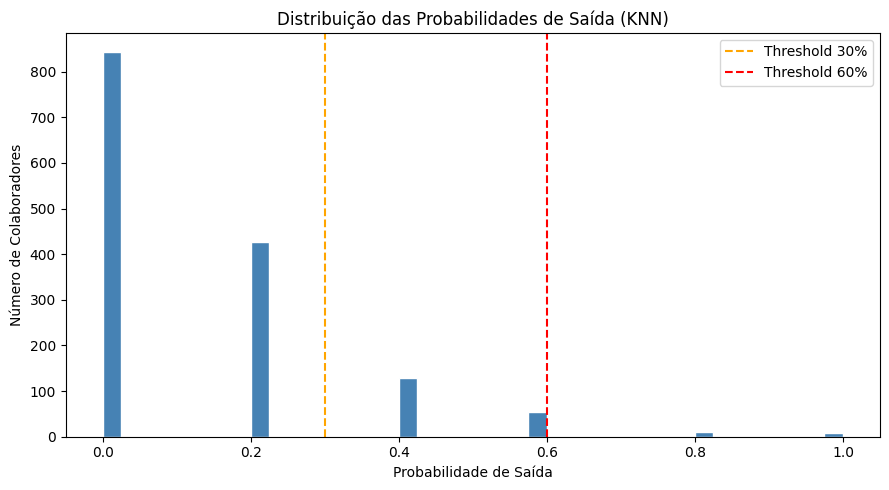

In [58]:
# 43. VISUALIZAÇÕES DO ÍNDICE DE RISCO (KNN)
import matplotlib.pyplot as plt

# 43.1 Histograma das probabilidades
fig, ax = plt.subplots(figsize=(9, 5))

# Usar o df_risco_knn do nosso modelo KNN
ax.hist(df_risco_knn["prob_saida"], bins=40, color="steelblue", edgecolor="white")

# Manter as linhas dos limiares (semáforo de risco)
ax.axvline(0.30, color="orange", linestyle="--", linewidth=1.5, label="Threshold 30%")
ax.axvline(0.60, color="red",    linestyle="--", linewidth=1.5, label="Threshold 60%")

ax.set_xlabel("Probabilidade de Saída")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Distribuição das Probabilidades de Saída (KNN)")
ax.legend()

plt.tight_layout()
# Guardar com um nome diferente para preservar as outras análises
plt.savefig("distribuicao_probabilidades_knn.png", dpi=150, bbox_inches="tight")
plt.show()

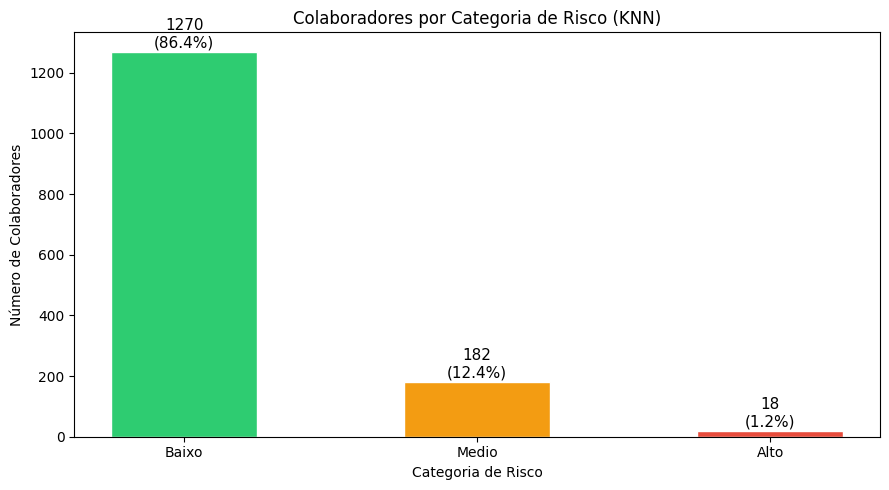

In [59]:
# 43.2 Contagem por categoria (KNN)
cores = {"Baixo": "#2ecc71", "Medio": "#f39c12", "Alto": "#e74c3c"}

fig, ax = plt.subplots(figsize=(9, 5))
# Ir buscar os valores às contagens do KNN
vals = [contagem_knn.get(c, 0) for c in ORDEM]

bars = ax.bar(ORDEM, vals, color=[cores[c] for c in ORDEM], edgecolor="white", width=0.5)

for bar, cat in zip(bars, ORDEM):
    n   = contagem_knn.get(cat, 0)
    pct = percentagem_knn.get(cat, 0.0)
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5, 
        f"{n}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=11
    )

ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Colaboradores por Categoria de Risco (KNN)")
plt.tight_layout()

# Guardar com um nome diferente para preservar a imagem do LDA
plt.savefig("categorias_risco_knn.png", dpi=150, bbox_inches="tight")
plt.show()

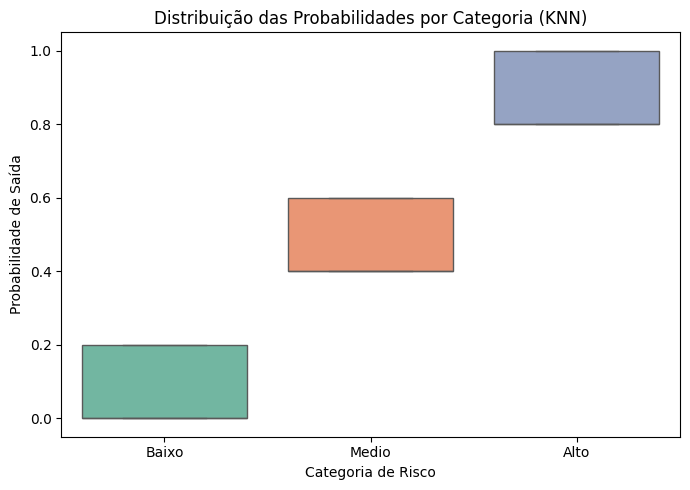

In [60]:
# 43.3 Boxplot por categoria (KNN)
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(7, 5))

# Usar o DataFrame do KNN
sns.boxplot(data=df_risco_knn, x="nivel_risco", y="prob_saida", order=ORDEM, ax=ax, palette="Set2")

ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Probabilidade de Saída")
ax.set_title("Distribuição das Probabilidades por Categoria (KNN)")

plt.tight_layout()
# Guardar com um novo nome para preservar a imagem do LDA
plt.savefig("boxplot_risco_knn.png", dpi=150, bbox_inches="tight")
plt.show()

In [61]:
# 44. RESUMO FINAL (KNN)

print("=" * 55)
print("RESUMO — KNN")
print("=" * 55)
print(f"  Modelo:         KNN (parâmetros default)")
print(f"  Colaboradores:  {len(df_risco_knn)}")
print(f"\n  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}")
print(f"  {'-'*32}")
for metrica, nome in [("acc","Accuracy"), ("precision","Precision"),
                       ("recall","Recall"), ("f1","F1-Score"), ("auc","AUC-ROC")]:
    print(f"  {nome:<12}  {resultados_treino_knn[metrica]:>8.4f}  {resultados_teste_knn[metrica]:>8.4f}")
print(f"\n  Baixo risco:    prob < 30%  -> {contagem_knn.get('Baixo', 0)} colaboradores")
print(f"  Risco medio:    30% - 60%   -> {contagem_knn.get('Medio', 0)} colaboradores")
print(f"  Alto risco:     prob > 60%  -> {contagem_knn.get('Alto', 0)} colaboradores")
print("=" * 55)

RESUMO — KNN
  Modelo:         KNN (parâmetros default)
  Colaboradores:  1470

  Métrica         Treino     Teste
  --------------------------------
  Accuracy        0.8767    0.8367
  Precision       0.8689    0.4545
  Recall          0.2789    0.1064
  F1-Score        0.4223    0.1724
  AUC-ROC         0.9163    0.6464

  Baixo risco:    prob < 30%  -> 1270 colaboradores
  Risco medio:    30% - 60%   -> 182 colaboradores
  Alto risco:     prob > 60%  -> 18 colaboradores


## Índice de Risco - Extra Trees 
Modelo Extra Trees com StandardScaler e classificação de risco.

In [62]:
# 45. TREINO — EXTRA TREES
pipeline_et = Pipeline([
    ("scaler", StandardScaler()),
    ("et", ExtraTreesClassifier(random_state=42)) 
])

pipeline_et.fit(X_train, y_train)
print("Modelo Extra Trees treinado.")

Modelo Extra Trees treinado.


In [63]:
# 46. AVALIAÇÃO NO CONJUNTO DE TREINO E TESTE (EXTRA TREES)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

def avaliar_modelo(pipeline, X, y, nome_conjunto):
    y_pred       = pipeline.predict(X)
    y_pred_proba = pipeline.predict_proba(X)[:, 1]

    acc       = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall    = recall_score(y, y_pred)
    f1        = f1_score(y, y_pred)
    auc       = roc_auc_score(y, y_pred_proba)

    print(f"===== METRICAS — {nome_conjunto} =====")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}")
    print()
    print(classification_report(y, y_pred, target_names=["Permaneceu", "Saiu"]))

    return {
        "conjunto":  nome_conjunto,
        "acc":       acc,
        "precision": precision,
        "recall":    recall,
        "f1":        f1,
        "auc":       auc,
        "y":         y,
        "y_proba":   y_pred_proba
    }

In [64]:
# 46.1 TREINO
resultados_treino_et = avaliar_modelo(pipeline_et, X_train, y_train, "Treino")

===== METRICAS — Treino =====
  F1-Score:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       986
        Saiu       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [65]:
# 46.2 TESTE
resultados_teste_et  = avaliar_modelo(pipeline_et, X_test,  y_test,  "Teste")

===== METRICAS — Teste =====
  F1-Score:  0.2143
  Precision: 0.6667
  Recall:    0.1277
  AUC-ROC:   0.8099

              precision    recall  f1-score   support

  Permaneceu       0.86      0.99      0.92       247
        Saiu       0.67      0.13      0.21        47

    accuracy                           0.85       294
   macro avg       0.76      0.56      0.57       294
weighted avg       0.83      0.85      0.80       294



In [66]:
# 47. COMPARAÇÃO TREINO vs TESTE (EXTRA TREES)

print("===== COMPARAÇÃO TREINO vs TESTE (EXTRA TREES) =====")
print(f"  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}  {'Diferença':>10}")
print(f"  {'-'*44}")

# Iterar sobre as métricas guardadas no dicionário
for metrica in ["acc", "precision", "recall", "f1", "auc"]:
    val_treino = resultados_treino_et[metrica]
    val_teste  = resultados_teste_et[metrica]
    diff       = val_treino - val_teste
    
    # Formatação do nome da métrica
    nome = metrica.upper() if metrica != "acc" else "Accuracy"
    
    print(f"  {nome:<12}  {val_treino:>8.4f}  {val_teste:>8.4f}  {diff:>+10.4f}")

# Validação automática de Overfitting focada no F1-Score
diff_f1_et = resultados_treino_et["f1"] - resultados_teste_et["f1"]

print() # Linha em branco para limpeza visual
if diff_f1_et > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== COMPARAÇÃO TREINO vs TESTE (EXTRA TREES) =====
  Métrica         Treino     Teste   Diferença
  --------------------------------------------
  Accuracy        1.0000    0.8503     +0.1497
  PRECISION       1.0000    0.6667     +0.3333
  RECALL          1.0000    0.1277     +0.8723
  F1              1.0000    0.2143     +0.7857
  AUC             1.0000    0.8099     +0.1901

  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


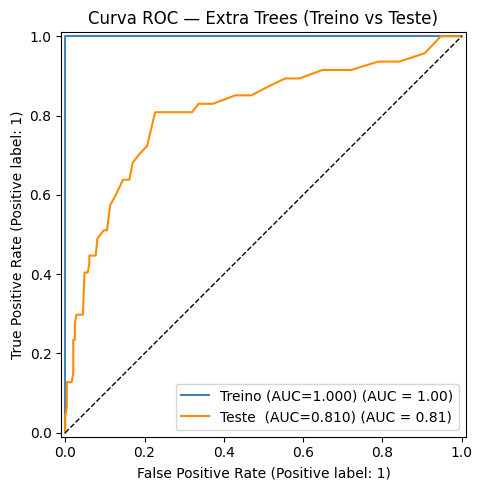

In [67]:
# 48. CURVAS ROC SOBREPOSTAS (EXTRA TREES)
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 5))

# Curva de Treino - Usando os resultados do Extra Trees
RocCurveDisplay.from_predictions(
    resultados_treino_et["y"], resultados_treino_et["y_proba"],
    name=f"Treino (AUC={resultados_treino_et['auc']:.3f})", ax=ax, color="steelblue"
)

# Curva de Teste - Usando os resultados do Extra Trees
RocCurveDisplay.from_predictions(
    resultados_teste_et["y"], resultados_teste_et["y_proba"],
    name=f"Teste  (AUC={resultados_teste_et['auc']:.3f})", ax=ax, color="darkorange"
)

# Linha de referência (o "acaso")
ax.plot([0, 1], [0, 1], "k--", lw=1)

ax.set_title("Curva ROC — Extra Trees (Treino vs Teste)")
plt.tight_layout()
# Salvando com um nome de arquivo diferente
plt.savefig("roc_treino_vs_teste_et.png", dpi=150, bbox_inches="tight")
plt.show()

In [68]:
# 49. GERAR PROBABILIDADES DE SAÍDA (dataset completo - EXTRA TREES)
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
df_completo = pd.read_csv(url)

# Aplicar a mesma preparação de features
cols_remover = ["Attrition", "OverTime", "Gender", "BusinessTravel", 
                "Department", "EducationField", "JobRole", "MaritalStatus"]
cols_remover = [c for c in cols_remover if c in df_completo.columns]

# Evitar erros caso a Attrition_bin não esteja no CSV
X_completo = df_completo.drop(columns=cols_remover + ["Attrition_bin"], errors='ignore')
X_completo = X_completo.select_dtypes(include=[np.number])

# Usamos df_risco_et para não sobrescrever o teu trabalho anterior
df_risco_et = df_completo.copy()

# A MUDANÇA PRINCIPAL: Chamar o pipeline do Extra Trees
df_risco_et["prob_saida"] = pipeline_et.predict_proba(X_completo)[:, 1]

print(f"Probabilidades geradas para {len(df_risco_et)} colaboradores (Extra Trees).")
print(df_risco_et["prob_saida"].describe(percentiles=[.25, .50, .75, .90]).round(4))

Probabilidades geradas para 1470 colaboradores (Extra Trees).
count    1470.0000
mean        0.1623
std         0.3355
min         0.0000
25%         0.0000
50%         0.0000
75%         0.1000
90%         1.0000
max         1.0000
Name: prob_saida, dtype: float64


In [69]:
# 50. CLASSIFICAÇÃO EM CATEGORIAS DE RISCO (EXTRA TREES)

def classificar_risco(prob):
    if prob < 0.30:
        return "Baixo"
    elif prob <= 0.60:
        return "Medio"
    else:
        return "Alto"

# Aplicar a função ao DataFrame do Extra Trees
df_risco_et["nivel_risco"] = df_risco_et["prob_saida"].apply(classificar_risco)

ORDEM = ["Baixo", "Medio", "Alto"]

contagem_et    = df_risco_et["nivel_risco"].value_counts()
percentagem_et = df_risco_et["nivel_risco"].value_counts(normalize=True) * 100

print("\n===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO (EXTRA TREES) =====")
print(f"  {'Categoria':<10}  {'Contagem':>8}  {'Percentagem':>12}")
print(f"  {'-'*34}")
for cat in ORDEM:
    n   = contagem_et.get(cat, 0)
    pct = percentagem_et.get(cat, 0.0)
    print(f"  {cat:<10}  {n:>8}  {pct:>11.1f}%")


===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO (EXTRA TREES) =====
  Categoria   Contagem   Percentagem
  ----------------------------------
  Baixo           1240         84.4%
  Medio             35          2.4%
  Alto             195         13.3%


In [70]:
# 51. ANÁLISE POR CATEGORIA DE RISCO (EXTRA TREES)

cols_analise = ["prob_saida", "Attrition_bin"]
# Adicionamos as variáveis de negócio para ver a "cara" de cada nível de risco
for col in ["Age", "MonthlyIncome", "JobLevel", "TotalWorkingYears", 
            "OverTime_bin", "SatisfactionIndex", "YearsAtCompany"]:
    if col in df_risco_et.columns:
        cols_analise.append(col)

print("\n===== PERFIL MÉDIO POR CATEGORIA DE RISCO (EXTRA TREES) =====")
perfil_et = df_risco_et.groupby("nivel_risco")[cols_analise].mean().reindex(ORDEM).round(3)
display(perfil_et)


===== PERFIL MÉDIO POR CATEGORIA DE RISCO (EXTRA TREES) =====


,prob_saida,Attrition_bin,Age,MonthlyIncome,JobLevel,TotalWorkingYears,OverTime_bin,SatisfactionIndex,YearsAtCompany
nivel_risco,,,,,,,,,
Baixo,0.024,0.021,37.689,6860.201,2.152,11.979,0.234,2.201,7.472
Medio,0.413,0.486,32.514,3523.029,1.286,5.371,0.714,2.114,2.886
Alto,0.994,0.995,32.851,4765.918,1.646,7.892,0.518,1.949,4.800


In [71]:
# 52. TOP 20 COLABORADORES COM MAIOR RISCO (EXTRA TREES)

cols_top = ["prob_saida", "nivel_risco", "Attrition_bin"]
for col in ["Age", "MonthlyIncome", "JobLevel", "OverTime_bin"]:
    if col in df_risco_et.columns:
        cols_top.append(col)

top20_et = df_risco_et.nlargest(20, "prob_saida")[cols_top].reset_index(drop=True)

print("\n===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (EXTRA TREES) =====")
display(top20_et)


===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (EXTRA TREES) =====


,prob_saida,nivel_risco,Attrition_bin,Age,MonthlyIncome,JobLevel,OverTime_bin
0,1.0,Alto,1,41,5993,2,1
1,1.0,Alto,1,28,2028,1,1
2,1.0,Alto,1,36,3407,1,0
3,1.0,Alto,1,32,3919,1,1
4,1.0,Alto,1,39,2086,2,0
5,1.0,Alto,1,24,2293,1,1
6,1.0,Alto,1,26,2293,1,0
7,1.0,Alto,1,48,5381,3,1
8,1.0,Alto,1,28,3441,1,1
9,1.0,Alto,1,46,9619,3,0


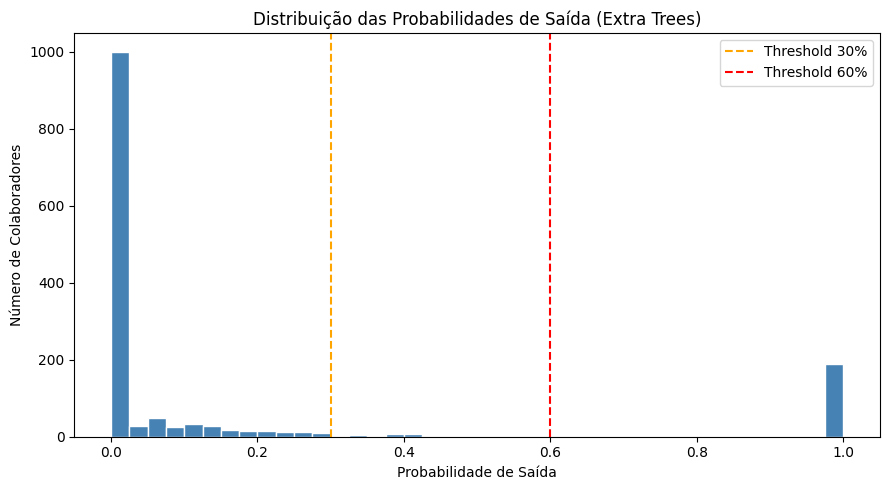

In [72]:
# 53. VISUALIZAÇÕES DO ÍNDICE DE RISCO (EXTRA TREES)
import matplotlib.pyplot as plt

# 53.1 Histograma das probabilidades
fig, ax = plt.subplots(figsize=(9, 5))

# Usar o df_risco_et do nosso modelo Extra Trees
ax.hist(df_risco_et["prob_saida"], bins=40, color="steelblue", edgecolor="white")

# Manter as linhas dos limiares (semáforo de risco)
ax.axvline(0.30, color="orange", linestyle="--", linewidth=1.5, label="Threshold 30%")
ax.axvline(0.60, color="red",    linestyle="--", linewidth=1.5, label="Threshold 60%")

ax.set_xlabel("Probabilidade de Saída")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Distribuição das Probabilidades de Saída (Extra Trees)")
ax.legend()

plt.tight_layout()
# Guardar com um nome diferente para preservar as outras análises
plt.savefig("distribuicao_probabilidades_et.png", dpi=150, bbox_inches="tight")
plt.show()

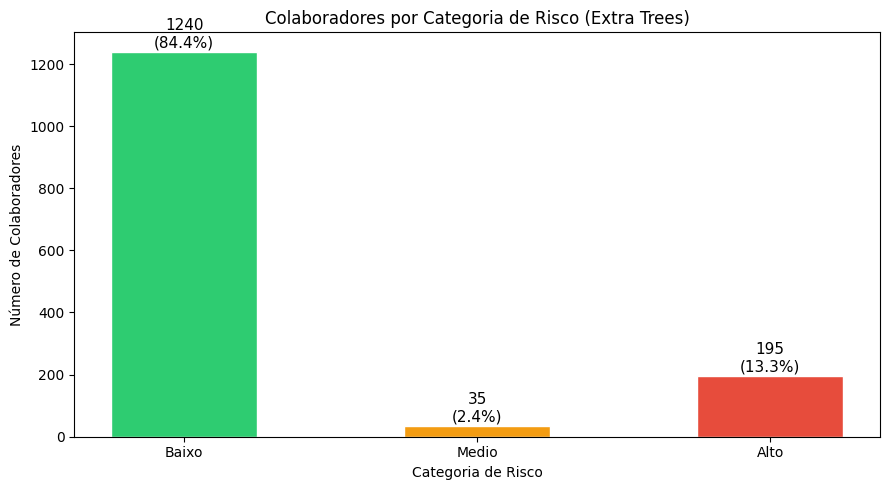

In [73]:
# 53.2 Contagem por categoria (EXTRA TREES)
cores = {"Baixo": "#2ecc71", "Medio": "#f39c12", "Alto": "#e74c3c"}

fig, ax = plt.subplots(figsize=(9, 5))
# Ir buscar os valores às contagens do Extra Trees
vals = [contagem_et.get(c, 0) for c in ORDEM]

bars = ax.bar(ORDEM, vals, color=[cores[c] for c in ORDEM], edgecolor="white", width=0.5)

for bar, cat in zip(bars, ORDEM):
    n   = contagem_et.get(cat, 0)
    pct = percentagem_et.get(cat, 0.0)
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5, 
        f"{n}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=11
    )

ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Colaboradores por Categoria de Risco (Extra Trees)")
plt.tight_layout()

# Guardar com um nome diferente para preservar a imagem do KNN
plt.savefig("categorias_risco_et.png", dpi=150, bbox_inches="tight")
plt.show()

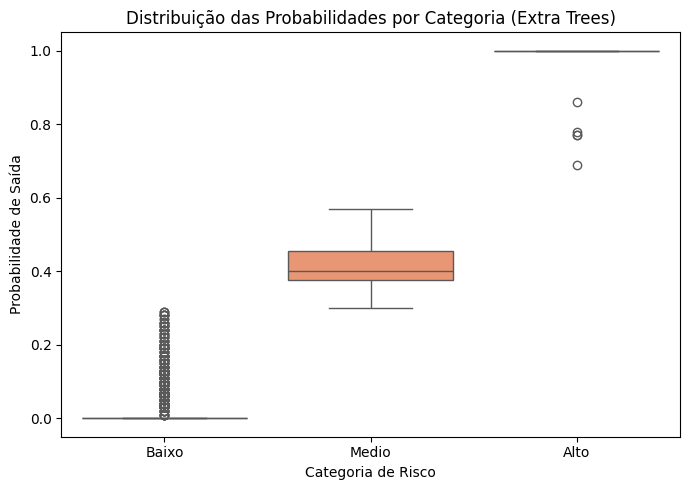

In [74]:
# 53.3 Boxplot por categoria (EXTRA TREES)
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(7, 5))

# Usar o DataFrame do Extra Trees
sns.boxplot(data=df_risco_et, x="nivel_risco", y="prob_saida", order=ORDEM, ax=ax, palette="Set2")

ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Probabilidade de Saída")
ax.set_title("Distribuição das Probabilidades por Categoria (Extra Trees)")

plt.tight_layout()
# Guardar com um novo nome para preservar a imagem do KNN
plt.savefig("boxplot_risco_et.png", dpi=150, bbox_inches="tight")
plt.show()

In [75]:
# 54. RESUMO FINAL (EXTRA TREES)

print("=" * 55)
print("RESUMO — EXTRA TREES")
print("=" * 55)
print(f"  Modelo:         Extra Trees (parâmetros default)")
print(f"  Colaboradores:  {len(df_risco_et)}")
print(f"\n  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}")
print(f"  {'-'*32}")
for metrica, nome in [("acc","Accuracy"), ("precision","Precision"),
                       ("recall","Recall"), ("f1","F1-Score"), ("auc","AUC-ROC")]:
    print(f"  {nome:<12}  {resultados_treino_et[metrica]:>8.4f}  {resultados_teste_et[metrica]:>8.4f}")
print(f"\n  Baixo risco:    prob < 30%  -> {contagem_et.get('Baixo', 0)} colaboradores")
print(f"  Risco medio:    30% - 60%   -> {contagem_et.get('Medio', 0)} colaboradores")
print(f"  Alto risco:     prob > 60%  -> {contagem_et.get('Alto', 0)} colaboradores")
print("=" * 55)

RESUMO — EXTRA TREES
  Modelo:         Extra Trees (parâmetros default)
  Colaboradores:  1470

  Métrica         Treino     Teste
  --------------------------------
  Accuracy        1.0000    0.8503
  Precision       1.0000    0.6667
  Recall          1.0000    0.1277
  F1-Score        1.0000    0.2143
  AUC-ROC         1.0000    0.8099

  Baixo risco:    prob < 30%  -> 1240 colaboradores
  Risco medio:    30% - 60%   -> 35 colaboradores
  Alto risco:     prob > 60%  -> 195 colaboradores


## Índice de Risco - SVM (SUPPORT VECTOR MACHINE)
Modelo SVM com StandardScaler e classificação de risco.

In [76]:
# 55. TREINO — SUPPORT VECTOR MACHINE (SVM)
pipeline_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=True, random_state=42)) 
])

pipeline_svm.fit(X_train, y_train)
print("Modelo Support Vector Machine (SVM) treinado.")

Modelo Support Vector Machine (SVM) treinado.


In [77]:
# 56. AVALIAÇÃO NO CONJUNTO DE TREINO E TESTE (SVM)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

def avaliar_modelo(pipeline, X, y, nome_conjunto):
    y_pred       = pipeline.predict(X)
    y_pred_proba = pipeline.predict_proba(X)[:, 1]

    acc       = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall    = recall_score(y, y_pred)
    f1        = f1_score(y, y_pred)
    auc       = roc_auc_score(y, y_pred_proba)

    print(f"===== METRICAS — {nome_conjunto} =====")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}")
    print()
    print(classification_report(y, y_pred, target_names=["Permaneceu", "Saiu"]))

    return {
        "conjunto":  nome_conjunto,
        "acc":       acc,
        "precision": precision,
        "recall":    recall,
        "f1":        f1,
        "auc":       auc,
        "y":         y,
        "y_proba":   y_pred_proba
    }

In [78]:
# 56.1 TREINO
resultados_treino_svm = avaliar_modelo(pipeline_svm, X_train, y_train, "Treino")

===== METRICAS — Treino =====
  F1-Score:  0.6851
  Precision: 1.0000
  Recall:    0.5211
  AUC-ROC:   0.9654

              precision    recall  f1-score   support

  Permaneceu       0.92      1.00      0.96       986
        Saiu       1.00      0.52      0.69       190

    accuracy                           0.92      1176
   macro avg       0.96      0.76      0.82      1176
weighted avg       0.93      0.92      0.91      1176



In [79]:
# 56.2 TESTE
resultados_teste_svm  = avaliar_modelo(pipeline_svm, X_test,  y_test,  "Teste")

===== METRICAS — Teste =====
  F1-Score:  0.2712
  Precision: 0.6667
  Recall:    0.1702
  AUC-ROC:   0.8086

              precision    recall  f1-score   support

  Permaneceu       0.86      0.98      0.92       247
        Saiu       0.67      0.17      0.27        47

    accuracy                           0.85       294
   macro avg       0.76      0.58      0.59       294
weighted avg       0.83      0.85      0.82       294



In [80]:
# 57. COMPARAÇÃO TREINO vs TESTE (SVM)

print("===== COMPARAÇÃO TREINO vs TESTE (SVM) =====")
print(f"  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}  {'Diferença':>10}")
print(f"  {'-'*44}")

# Iterar sobre as métricas guardadas no dicionário do SVM
for metrica in ["acc", "precision", "recall", "f1", "auc"]:
    val_treino = resultados_treino_svm[metrica]
    val_teste  = resultados_teste_svm[metrica]
    diff       = val_treino - val_teste
    
    # Formatação do nome da métrica
    nome = metrica.upper() if metrica != "acc" else "Accuracy"
    
    print(f"  {nome:<12}  {val_treino:>8.4f}  {val_teste:>8.4f}  {diff:>+10.4f}")

# Validação automática de Overfitting focada no F1-Score
diff_f1_svm = resultados_treino_svm["f1"] - resultados_teste_svm["f1"]

print() # Linha em branco para limpeza visual
if diff_f1_svm > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting (Modelo Estável).")

===== COMPARAÇÃO TREINO vs TESTE (SVM) =====
  Métrica         Treino     Teste   Diferença
  --------------------------------------------
  Accuracy        0.9226    0.8537     +0.0689
  PRECISION       1.0000    0.6667     +0.3333
  RECALL          0.5211    0.1702     +0.3508
  F1              0.6851    0.2712     +0.4139
  AUC             0.9654    0.8086     +0.1568

  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


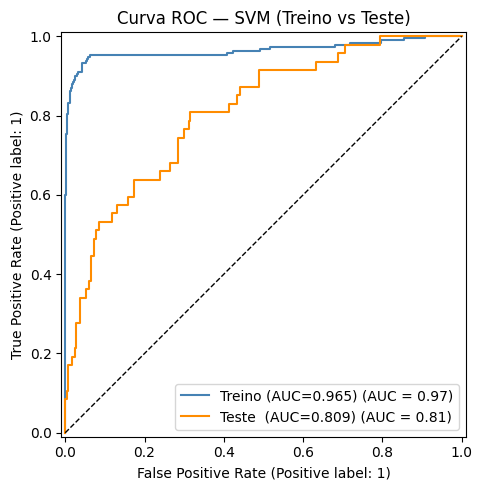

In [81]:
# 58. CURVAS ROC SOBREPOSTAS (SVM)
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 5))

# Curva de Treino - Usando os resultados do SVM
RocCurveDisplay.from_predictions(
    resultados_treino_svm["y"], resultados_treino_svm["y_proba"],
    name=f"Treino (AUC={resultados_treino_svm['auc']:.3f})", ax=ax, color="steelblue"
)

# Curva de Teste - Usando os resultados do SVM
RocCurveDisplay.from_predictions(
    resultados_teste_svm["y"], resultados_teste_svm["y_proba"],
    name=f"Teste  (AUC={resultados_teste_svm['auc']:.3f})", ax=ax, color="darkorange"
)

# Linha de referência (o "acaso")
ax.plot([0, 1], [0, 1], "k--", lw=1)

ax.set_title("Curva ROC — SVM (Treino vs Teste)")
plt.tight_layout()

# Salvando com o nome do modelo atual
plt.savefig("roc_treino_vs_teste_svm.png", dpi=150, bbox_inches="tight")
plt.show()

In [82]:
# 59. GERAR PROBABILIDADES DE SAÍDA (dataset completo - SVM)
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
df_completo = pd.read_csv(url)

# Aplicar a mesma preparação de features
cols_remover = ["Attrition", "OverTime", "Gender", "BusinessTravel", 
                "Department", "EducationField", "JobRole", "MaritalStatus"]
cols_remover = [c for c in cols_remover if c in df_completo.columns]

# Evitar erros caso a Attrition_bin não esteja no CSV
X_completo = df_completo.drop(columns=cols_remover + ["Attrition_bin"], errors='ignore')
X_completo = X_completo.select_dtypes(include=[np.number])

# Usamos df_risco_svm para não sobrescrever o trabalho do Extra Trees ou KNN
df_risco_svm = df_completo.copy()

# A MUDANÇA PRINCIPAL: Chamar o pipeline do SVM
df_risco_svm["prob_saida"] = pipeline_svm.predict_proba(X_completo)[:, 1]

print(f"Probabilidades geradas para {len(df_risco_svm)} colaboradores (SVM).")
print(df_risco_svm["prob_saida"].describe(percentiles=[.25, .50, .75, .90]).round(4))

Probabilidades geradas para 1470 colaboradores (SVM).
count    1470.0000
mean        0.1626
std         0.2354
min         0.0016
25%         0.0370
50%         0.0851
75%         0.1051
90%         0.5234
max         0.9926
Name: prob_saida, dtype: float64


In [83]:
# 60. CLASSIFICAÇÃO EM CATEGORIAS DE RISCO (SVM)

def classificar_risco(prob):
    if prob < 0.30:
        return "Baixo"
    elif prob <= 0.60:
        return "Medio"
    else:
        return "Alto"

# Aplicar a função ao DataFrame do SVM
df_risco_svm["nivel_risco"] = df_risco_svm["prob_saida"].apply(classificar_risco)

ORDEM = ["Baixo", "Medio", "Alto"]

contagem_svm    = df_risco_svm["nivel_risco"].value_counts()
percentagem_svm = df_risco_svm["nivel_risco"].value_counts(normalize=True) * 100

print("\n===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO (SVM) =====")
print(f"  {'Categoria':<10}  {'Contagem':>8}  {'Percentagem':>12}")
print(f"  {'-'*34}")
for cat in ORDEM:
    n   = contagem_svm.get(cat, 0)
    pct = percentagem_svm.get(cat, 0.0)
    print(f"  {cat:<10}  {n:>8}  {pct:>11.1f}%")


===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO (SVM) =====
  Categoria   Contagem   Percentagem
  ----------------------------------
  Baixo           1256         85.4%
  Medio             84          5.7%
  Alto             130          8.8%


In [84]:
# 61. ANÁLISE POR CATEGORIA DE RISCO (SVM)

cols_analise = ["prob_saida", "Attrition_bin"]
# Adicionamos as variáveis de negócio para ver a "cara" de cada nível de risco
for col in ["Age", "MonthlyIncome", "JobLevel", "TotalWorkingYears", 
            "OverTime_bin", "SatisfactionIndex", "YearsAtCompany"]:
    if col in df_risco_svm.columns:
        cols_analise.append(col)

print("\n===== PERFIL MÉDIO POR CATEGORIA DE RISCO (SVM) =====")
perfil_svm = df_risco_svm.groupby("nivel_risco")[cols_analise].mean().reindex(ORDEM).round(3)
display(perfil_svm)


===== PERFIL MÉDIO POR CATEGORIA DE RISCO (SVM) =====


,prob_saida,Attrition_bin,Age,MonthlyIncome,JobLevel,TotalWorkingYears,OverTime_bin,SatisfactionIndex,YearsAtCompany
nivel_risco,,,,,,,,,
Baixo,0.074,0.044,37.834,6877.959,2.158,12.010,0.235,2.206,7.506
Medio,0.437,0.702,33.298,4910.250,1.655,8.250,0.536,2.060,5.190
Alto,0.838,0.946,30.469,3908.700,1.415,6.177,0.585,1.838,3.369


In [85]:
# 62. TOP 20 COLABORADORES COM MAIOR RISCO (SVM)

cols_top = ["prob_saida", "nivel_risco", "Attrition_bin"]
for col in ["Age", "MonthlyIncome", "JobLevel", "OverTime_bin"]:
    if col in df_risco_svm.columns:
        cols_top.append(col)

# Usar o DataFrame do SVM para encontrar os 20 casos mais críticos
top20_svm = df_risco_svm.nlargest(20, "prob_saida")[cols_top].reset_index(drop=True)

print("\n===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (SVM) =====")
display(top20_svm)


===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (SVM) =====


,prob_saida,nivel_risco,Attrition_bin,Age,MonthlyIncome,JobLevel,OverTime_bin
0,0.992620,Alto,1,18,1878,1,1
1,0.991179,Alto,1,31,1359,1,0
2,0.990970,Alto,1,24,3172,1,1
3,0.990518,Alto,1,26,2340,1,1
4,0.988481,Alto,1,32,2795,1,1
5,0.983114,Alto,1,25,1118,1,1
6,0.982749,Alto,1,18,1569,1,1
7,0.981282,Alto,1,21,2174,1,1
8,0.976864,Alto,1,23,1790,1,0
9,0.976849,Alto,1,32,3919,1,1


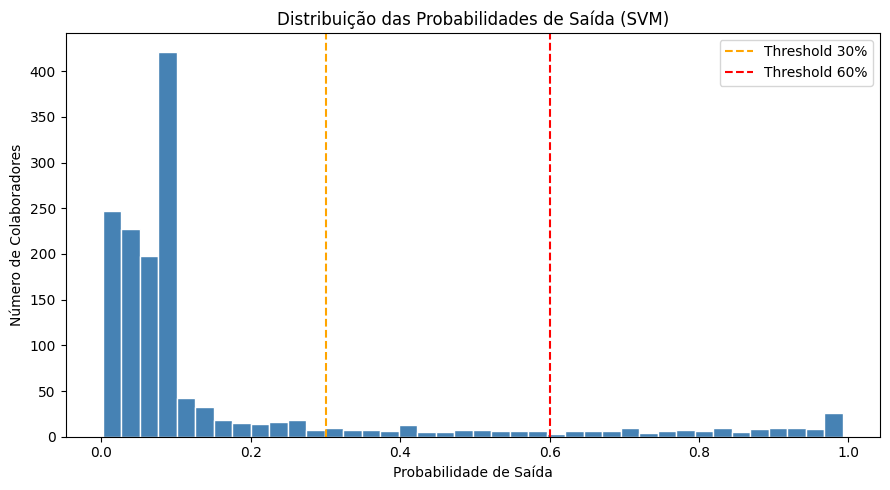

In [86]:
# 63. VISUALIZAÇÕES DO ÍNDICE DE RISCO (SVM)
import matplotlib.pyplot as plt

# 63.1 Histograma das probabilidades
fig, ax = plt.subplots(figsize=(9, 5))

# Usar o df_risco_svm do nosso modelo SVM
ax.hist(df_risco_svm["prob_saida"], bins=40, color="steelblue", edgecolor="white")

# Manter as linhas dos limiares (semáforo de risco)
ax.axvline(0.30, color="orange", linestyle="--", linewidth=1.5, label="Threshold 30%")
ax.axvline(0.60, color="red",    linestyle="--", linewidth=1.5, label="Threshold 60%")

ax.set_xlabel("Probabilidade de Saída")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Distribuição das Probabilidades de Saída (SVM)")
ax.legend()

plt.tight_layout()
# Guardar com um nome diferente para preservar as outras análises
plt.savefig("distribuicao_probabilidades_svm.png", dpi=150, bbox_inches="tight")
plt.show()

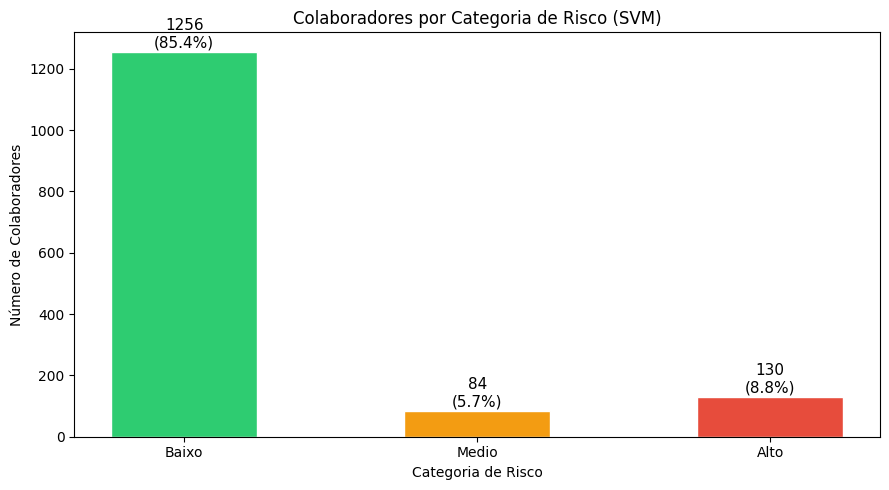

In [87]:
# 63.2 Contagem por categoria (SVM)
cores = {"Baixo": "#2ecc71", "Medio": "#f39c12", "Alto": "#e74c3c"}

fig, ax = plt.subplots(figsize=(9, 5))
# Ir buscar os valores às contagens do SVM
vals = [contagem_svm.get(c, 0) for c in ORDEM]

bars = ax.bar(ORDEM, vals, color=[cores[c] for c in ORDEM], edgecolor="white", width=0.5)

for bar, cat in zip(bars, ORDEM):
    n   = contagem_svm.get(cat, 0)
    pct = percentagem_svm.get(cat, 0.0)
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5, 
        f"{n}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=11
    )

ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Colaboradores por Categoria de Risco (SVM)")
plt.tight_layout()

# Guardar com um nome diferente para preservar as imagens anteriores
plt.savefig("categorias_risco_svm.png", dpi=150, bbox_inches="tight")
plt.show()

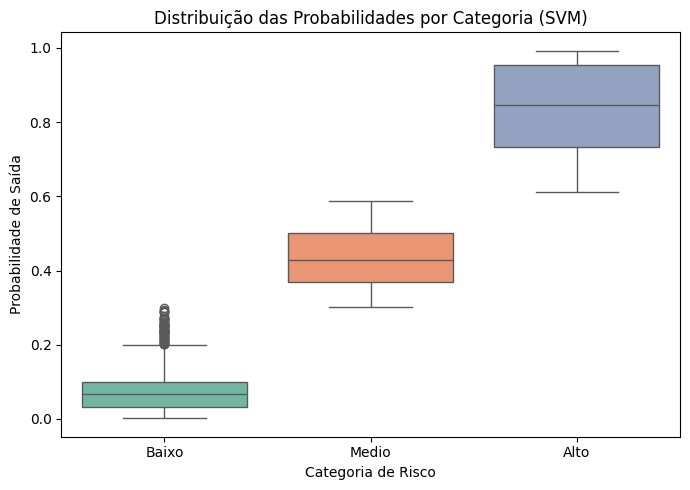

In [88]:
# 63.3 Boxplot por categoria (SVM)
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(7, 5))

# Usar o DataFrame do SVM
sns.boxplot(data=df_risco_svm, x="nivel_risco", y="prob_saida", order=ORDEM, ax=ax, palette="Set2")

ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Probabilidade de Saída")
ax.set_title("Distribuição das Probabilidades por Categoria (SVM)")

plt.tight_layout()
# Guardar com um novo nome para preservar a imagem do Extra Trees
plt.savefig("boxplot_risco_svm.png", dpi=150, bbox_inches="tight")
plt.show()

In [89]:
# 54. RESUMO FINAL (SVM)

print("=" * 55)
print("RESUMO — SVM")
print("=" * 55)
print(f"  Modelo:         Support Vector Machine (SVC)")
print(f"  Colaboradores:  {len(df_risco_svm)}")
print(f"\n  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}")
print(f"  {'-'*32}")
for metrica, nome in [("acc","Accuracy"), ("precision","Precision"),
                       ("recall","Recall"), ("f1","F1-Score"), ("auc","AUC-ROC")]:
    print(f"  {nome:<12}  {resultados_treino_svm[metrica]:>8.4f}  {resultados_teste_svm[metrica]:>8.4f}")
print(f"\n  Baixo risco:    prob < 30%  -> {contagem_svm.get('Baixo', 0)} colaboradores")
print(f"  Risco medio:    30% - 60%   -> {contagem_svm.get('Medio', 0)} colaboradores")
print(f"  Alto risco:     prob > 60%  -> {contagem_svm.get('Alto', 0)} colaboradores")
print("=" * 55)

RESUMO — SVM
  Modelo:         Support Vector Machine (SVC)
  Colaboradores:  1470

  Métrica         Treino     Teste
  --------------------------------
  Accuracy        0.9226    0.8537
  Precision       1.0000    0.6667
  Recall          0.5211    0.1702
  F1-Score        0.6851    0.2712
  AUC-ROC         0.9654    0.8086

  Baixo risco:    prob < 30%  -> 1256 colaboradores
  Risco medio:    30% - 60%   -> 84 colaboradores
  Alto risco:     prob > 60%  -> 130 colaboradores
